<img src="logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

# Exploratory Data Analysis: Premier League

## Purpose

This notebook presents a teaching example of **exploratory data analysis (EDA)**. Its goal is to understand the dataset's structure, quality, and patterns before building a model to predict the result of a football match.

EDA is not intended to prove causality or make final modeling decisions. It aims to:

- detect data quality issues;
- describe distributions and relationships;
- formulate hypotheses;
- acknowledge uncertainty and limitations;
- propose decisions that must later be validated.

**Unit of observation:** Un partido de futbol de la liga inglesa  
**Target variable:** `FTR` Full Time Result (`H`=Home Win, `D`=Draw, `A`=Away Win)  
**Downstream problem type:** Clasificacion Multiclase.


## Guiding questions

1. Which variables and data types does the dataset contain?
2. Are there duplicates, missing values, or suspicious values?
3. How is the target variable distributed?
4. How is the result associated with home/away, season, half-time result, and team strength?
5. Are there relevant interactions between variables?
6. What useful information can be extracted from the bookmaker odds?
7. Which preprocessing hypotheses should be validated during modeling?

> The observed associations describe this sample. By themselves, they do not imply causal relationships.


In [87]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

DATA_FOLDER = "data/processed"
DATASET_NAME = "premier_league_2021_2026.csv"

MAX_ROWS = 50
MAX_COLS = 50

# Allow execution from either the project root or the notebooks/ directory.
PROJECT_ROOT = Path.cwd()
print(PROJECT_ROOT)
if not (PROJECT_ROOT  / DATA_FOLDER / DATASET_NAME ).exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / DATA_FOLDER / DATASET_NAME
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}"

pd.set_option("display.max_columns", MAX_COLS)
pd.set_option("display.max_rows", MAX_ROWS)
pd.set_option("display.float_format", "{:.3f}".format)
plt.style.use("seaborn-v0_8-whitegrid")


c:\Users\Benja\Documents\machine learning\premier_league_football_predictor\notebooks


In [88]:
premier_df = pd.read_csv(DATA_PATH)

print(f"Dimensions: {premier_df.shape[0]} rows × {premier_df.shape[1]} columns")
premier_df.head()


Dimensions: 1900 rows × 157 columns


,Season,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,...,BFECAHA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,CLH,CLD,CLA,LBH,LBD,LBA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,2021-2022,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,H,M Oliver,8,22,3,4,12,8,2,5,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-2022,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,H,P Tierney,16,10,8,3,11,9,5,4,1,2,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-2022,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,H,D Coote,14,14,3,8,10,7,7,6,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-2022,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,H,J Moss,13,4,6,1,15,11,5,2,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-2022,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,A,A Madley,14,6,6,3,13,15,6,8,2,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 1. Data understanding and quality

We begin by examining the dataset's structure. The data types stored by pandas do not always match each variable's analytical role:

- `Season` es un identificador de la temporada de la que provienen los datos, aunque se guarda como string.
- `Div` indica la división de la liga y también se guarda como string; solo contiene un valor (`E0`).
- `Date` y `Time` son strings que representan la fecha y la hora del partido.
- `HomeTeam` y `AwayTeam` contienen textos con los nombres de los equipos.
- `FTR` y `HTR` son los resultados del partido completo y del medio tiempo, respectivamente: categóricos entre (`H` = Home, `A` = Away, `D` = Draw). `FTR` es la variable objetivo.
- `FTHG`, `FTAG`, `HTHG` y `HTAG` son los goles: conteos discretos almacenados como enteros.
- `Referee` es el nombre del árbitro: categórico de alta cardinalidad (40 árbitros en 1900 partidos) cuyo rol predictivo es dudoso.
- Las columnas de estadísticas del partido (`HS`, `AS`, `HST`, `AST`, `HF`, `AF`, `HC`, `AC`, `HY`, `AY`, `HR`, `AR`) son conteos discretos que solo se conocen después del final del partido: no sirven para predecir (riesgo de fuga de información).
- Las columnas de cuotas (`B365H`, `AvgH`, `MaxA`, `AHh`, ...) son numéricas y codifican la probabilidad implícita que el mercado asigna a cada resultado. Cubren varios mercados (1X2, más/menos 2.5 goles, handicap asiático y sus versiones de cierre) y varias casas de apuestas.
- El identificador de cada partido es compuesto: `Season`, `Div`, `Date`, `Time`, `HomeTeam` y `AwayTeam` juntos identifican una fila.


# in english
- `Season` serves as an identifier for the season the data originates from, although it is stored as a string.
- `Div` indicates the league division and is also stored as a string; it contains only a single unique value (`E0`).
- `Date` and `Time` are strings representing the date and time of the match.
- `HomeTeam` and `AwayTeam` contain string values representing the team names.
- `FTR` and `HTR` represent the full-time and half-time match results, respectively: categorical variables encoded as (`H` = Home, `A` = Away, `D` = Draw). `FTR` is the target variable.
- `FTHG`, `FTAG`, `HTHG`, and `HTAG` denote the goals scored: discrete counts stored as integers.
- `Referee` refers to the referee's name: a high-cardinality categorical feature (40 referees across 1900 matches) whose predictive power is doubtful.
- The match statistics columns (`HS`, `AS`, `HST`, `AST`, `HF`, `AF`, `HC`, `AC`, `HY`, `AY`, `HR`, `AR`) are discrete counts that are only known after the match concludes: they are unsuitable for prediction purposes (high risk of data leakage).
- The betting odds columns (`B365H`, `AvgH`, `MaxA`, `AHh`, ...) are numerical features that encode the implied probability assigned by the market to each outcome. They cover various markets (1X2, Over/Under 2.5 goals, Asian Handicap, and their closing line versions) across multiple bookmakers.
- The match identifier is composite: `Season`, `Div`, `Date`, `Time`, `HomeTeam`, and `AwayTeam` jointly form a composite key that uniquely identifies a single row.

In [89]:
premier_df.info( verbose=True, show_counts=True )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 157 columns):
 #    Column     Non-Null Count  Dtype  
---   ------     --------------  -----  
 0    Season     1900 non-null   object 
 1    Div        1900 non-null   object 
 2    Date       1900 non-null   object 
 3    Time       1900 non-null   object 
 4    HomeTeam   1900 non-null   object 
 5    AwayTeam   1900 non-null   object 
 6    FTHG       1900 non-null   int64  
 7    FTAG       1900 non-null   int64  
 8    FTR        1900 non-null   object 
 9    HTHG       1900 non-null   int64  
 10   HTAG       1900 non-null   int64  
 11   HTR        1900 non-null   object 
 12   Referee    1900 non-null   object 
 13   HS         1900 non-null   int64  
 14   AS         1900 non-null   int64  
 15   HST        1900 non-null   int64  
 16   AST        1900 non-null   int64  
 17   HF         1900 non-null   int64  
 18   AF         1900 non-null   int64  
 19   HC         1900 non-null 

In [90]:
quality_summary = pd.DataFrame({
    "dtype": premier_df.dtypes.astype(str),
    "missing_n": premier_df.isna().sum(),
    "missing_pct": premier_df.isna().mean().mul(100),
    "unique_n": premier_df.nunique(dropna=True),
})
quality_summary.sort_values("missing_pct", ascending=False )


,dtype,missing_n,missing_pct,unique_n
CLCH,float64,1640,86.316,73
CLCA,float64,1640,86.316,68
CLCD,float64,1640,86.316,30
LBCH,float64,1619,85.211,74
LBCD,float64,1619,85.211,30
...,...,...,...,...
AvgC<2.5,float64,0,0.000,225
AvgCAHA,float64,0,0.000,52
AHCh,float64,0,0.000,23
AvgCAHH,float64,0,0.000,47


In [91]:
checks = pd.Series({
    "duplicated_rows": premier_df.duplicated().sum(),
    "negative_goals_home": premier_df["FTHG"].lt(0).sum(),
    "negative_goals_away": premier_df["FTAG"].lt(0).sum(),
    "negative_goals_home_half_time": premier_df["HTHG"].lt(0).sum(),
    "negative_goals_away_half_time": premier_df["HTAG"].lt(0).sum(),
    "draw_match": ( premier_df[ "FTR" ] == "D" ).sum(),
    "home_win_match": ( premier_df[ "FTR" ] == "H" ).sum(),
    "away_win_match": ( premier_df[ "FTR" ] == "A" ).sum(),
    "yellow_card_negative_home": premier_df[ "HY" ].lt(0).sum(),
    "yellow_card_negative_away": premier_df[ "AY" ].lt(0).sum(),
    "negative_shots_home": premier_df["HS"].lt(0).sum(),
    "negative_shots_away": premier_df["AS"].lt(0).sum(),
    "negative_shots_at_target_home": premier_df["HST"].lt(0).sum(),
    "negative_shots_at_target_away": premier_df["AST"].lt(0).sum(),
    "negative_fouls_home": premier_df["HF"].lt(0).sum(),
    "negative_fouls_away": premier_df["AF"].lt(0).sum(),
    "negative_corners_home": premier_df["HC"].lt(0).sum(),
    "negative_corners_away": premier_df["AC"].lt(0).sum(),
    "Referee_null_name":premier_df["Referee"].isna().sum(),
    "ht_goals_gt_ft_home": (premier_df["HTHG"] > premier_df["FTHG"]).sum(),
    "ht_goals_gt_ft_away": (premier_df["HTAG"] > premier_df["FTAG"]).sum(),
    "false_draw": ((premier_df["FTHG"] != premier_df["FTAG"]) & (premier_df["FTR"] == "D")).sum(),
    "false_home_win": ((premier_df["FTHG"] <= premier_df["FTAG"]) & (premier_df["FTR"] == "H")).sum(),
    "false_away_win": ((premier_df["FTAG"] <= premier_df["FTHG"]) & (premier_df["FTR"] == "A")).sum(),
    "impossible_shots_target_home": (premier_df["HST"] > premier_df["HS"]).sum(),
    "impossible_shots_target_away": (premier_df["AST"] > premier_df["AS"]).sum(),
    "excessive_red_cards_home": (premier_df["HR"] > 5).sum(),
    "excessive_red_cards_away": (premier_df["AR"] > 5).sum(),
})
checks.to_frame("count")


,count
duplicated_rows,0
negative_goals_home,0
negative_goals_away,0
negative_goals_home_half_time,0
negative_goals_away_half_time,0
draw_match,454
home_win_match,839
away_win_match,607
yellow_card_negative_home,0
yellow_card_negative_away,0


In [92]:
error_shots = premier_df[premier_df["AST"] > premier_df["AS"]]

see_columns = ["Date", "HomeTeam", "AwayTeam", "AS", "AST"]
print(error_shots[see_columns])


         Date   HomeTeam  AwayTeam  AS  AST
8  15/08/2021  Newcastle  West Ham   8    9


### Data quality observations

- La mayoria de datos faltantes se tratan de las casas de apuesta, muchos de estos se deben por el hecho de que no todos participan en las mismas temporadas
- El identificador es compuesto por `Season`, `Div`, `Date`, `Time`, `HomeTeam` y `AwayTeam` donde la Season, HomeTeam y AwayTeam son las variables mas probables a afectar en los resultados
- No se encuentran valores negativos dentro de las validaciones realizadas
- Se encuentra una incongruencia dentro de los tiros y tiros hacia el arco, en un partido lo que no es logico, pero despues de una busqueda del partido se encontraron los datos originales.
- Se han encontrado 454 partidos que han resultados en empate
- `HomeTeam` y `AwayTeam` tienen la misma cardinalidad pero por el hecho de que contamos con 27 equipos
- Hay centros de apuestas que faltan un 80% de sus datos, por lo que se esta planteando no tomarlos tanto en cuenta como los centros de 1XB
- Justamente revisamos el partido de `Newcastle` VS `West Ham` y en efecto se escribio mal el numero de tiro del visitante, ya que en realidad eran `18` y no `8`

# in english 
- The majority of missing values belong to the bookmaker features, largely due to the fact that not all of them operate across the same seasons.
- The identifier is a composite key consisting of `Season`, `Div`, `Date`, `Time`, `HomeTeam`, and `AwayTeam`, where the `Season`, `HomeTeam`, and `AwayTeam` are the features most likely to impact the target variable.
- No negative values were detected during the data validation checks.
- An inconsistency was identified between the total shots and shots on target for a specific match—a logical constraint violation. However, upon cross-referencing the match, the ground truth data was retrieved.
- A total of 454 matches resulted in a draw.
- `HomeTeam` and `AwayTeam` exhibit the exact same cardinality due to the dataset comprising 27 unique teams.
- Several bookmaker features present a missing data rate of 80%; consequently, we are considering dropping these features or downweighting them compared to the 1XB bookmakers.
- Specifically, upon reviewing the `Newcastle` vs `West Ham` match, a data entry error was confirmed regarding the away team's total shots: the true value was `18`, rather than `8`.


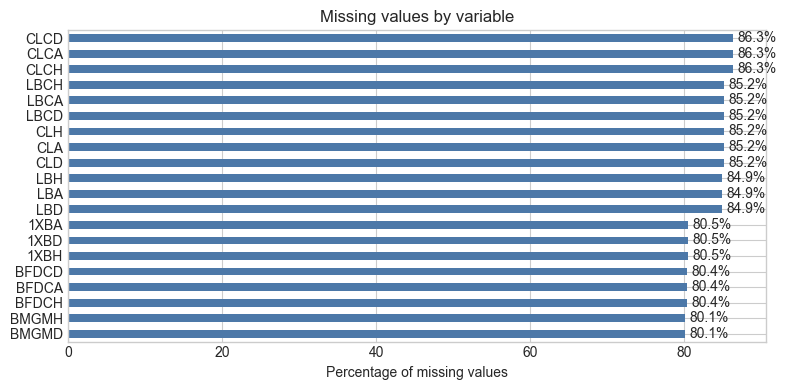

In [93]:
missing_pct = premier_df.isna().mean().mul(100).sort_values().tail(20)

fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="barh", ax=ax, color="#4C78A8")
ax.set(title="Missing values by variable", xlabel="Percentage of missing values", ylabel="")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


- Aca podemos ver la cantidad de datos faltantes donde se encuentra centralizado mas que todo dentro de las casas de apuestas

#  in english 
- Here we can observe the distribution of missing values, which are heavily concentrated within the bookmaker features.

# 2. La variable objetivo (el resultado)

Además de ver cómo se reparten los resultados, calculamos un **punto de partida**: un modelo que siempre predice la clase más frecuente (victoria local, `H`) acertaría un 44.2% de las veces. Cualquier modelo tiene que superar ese número. Y como hay tres resultados y no están repartidos por igual, conviene mirar el acierto por separado para cada resultado (local, empate, visitante) en vez de solo el porcentaje total de aciertos.

# in english 

# 2. The target variable (the result)

In addition to analyzing the class distribution, we established a **baseline**: a naive model that consistently predicts the majority class (home win, `H`) would yield an accuracy of 44.2%. Any predictive model must outperform this threshold. Furthermore, due to the multi-class nature of the problem and the inherent class imbalance, it is advisable to evaluate performance metrics per class (home, draw, away) rather than relying solely on overall accuracy.

In [94]:
target_summary = (
    premier_df["FTR"]
    .value_counts()
    .rename(index={"H": "Home Win", "D": "Draw", "A": "Away Win"})
    .to_frame("n")
)
target_summary["pct"] = target_summary["n"].div(len(premier_df)).mul(100)
target_summary


,n,pct
FTR,,
Home Win,839,44.158
Away Win,607,31.947
Draw,454,23.895


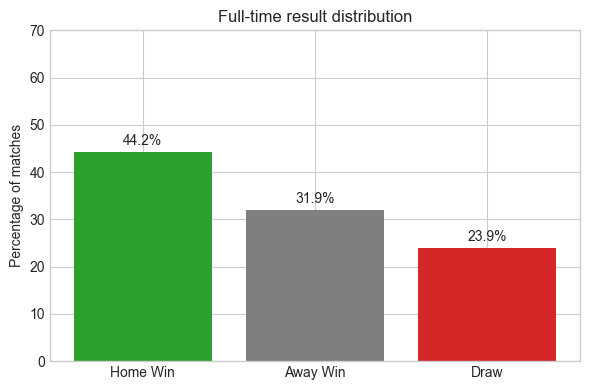

In [95]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(target_summary.index, target_summary["pct"], color=["#2CA02C", "#7F7F7F", "#D62728"])
ax.set(title="Full-time result distribution", ylabel="Percentage of matches", ylim=(0, 70))
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.show()


### Interpretación

- **Observación:** De cada 100 partidos, unos 44 los gana el equipo de casa, unos 32 los gana el visitante y unos 24 acaban en empate.
- **Interpretación:** Se ve que jugar en casa ayuda: el equipo local gana bastante más seguido que el visitante (como 12 de cada 100 partidos más). El empate es lo más raro de todo.
- **Decisión/Hipótesis:** Si tuviéramos que apostar a ciegas, lo más sensato sería decir siempre "gana el de casa", y acertaríamos unas 44 de cada 100 veces. Cualquier modelo tiene que hacerlo mejor que eso. Y como ganar en casa es tan frecuente, conviene mirar cuánto acierta el modelo en cada tipo de resultado (local, empate, visitante), no solo cuántos aciertos tiene en total.

# in english 

### Interpretation

- **Observation:** The empirical class distribution indicates that out of every 100 matches, approximately 44 are home wins, 32 are away wins, and 24 result in a draw.
- **Interpretation:** A pronounced home-field advantage is evident: the home team secures victories significantly more often than the away team (a margin of roughly 12 percentage points). A draw represents the minority class.
- **Decision/Hypothesis:** If predicting blindly, adopting a naive baseline that constantly predicts the majority class ("home win") would yield an accuracy of roughly 44%. Any predictive model must strictly outperform this baseline metric. Furthermore, given the inherent class imbalance, it is imperative to evaluate performance using per-class metrics (home, draw, away) rather than relying exclusively on overall accuracy.


# 3. Categorical variables and match outcome

To avoid misleading interpretations, the following tables report the group size (`n`) and the breakdown of outcomes (`H`, `D`, `A`) together.

# other way say it 

# 3. Categorical features and match outcome

To mitigate the risk of spurious interpretations, the subsequent cross-tabulations present the support (`n`) alongside the empirical class distribution of the outcomes (`H`, `D`, `A`) simultaneously.


In [96]:

def match_outcomes_summary(data, group_cols, target_col):
    """
    Summarize the number of matches and the breakdown of outcomes (H, D, A)
    for any grouping of variables.
    """
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    
    # 1. Group and count the frequencies of each class (H, D, A)
    summary = (
        data.groupby(group_cols, observed=True)[target_col]
        .value_counts()
        .unstack(fill_value=0) # Converts class rows into columns
    )
    
    # 2. Compute the total number of matches for that group
    summary["Total"] = summary.sum(axis=1)
    
    # 3. Compute percentages dynamically for each existing class
    # Use the actual classes found in the pivot table
    classes = [col for col in summary.columns if col != "Total"]
    
    for col in classes:
        summary[f"{col}_pct"] = (summary[col] / summary["Total"] * 100).round(2)
        
    return summary

# --- APPLICATION ---

# Breakdown of the final result (FTR) by Season
season_ftr_summary = match_outcomes_summary(premier_df, "Season", "FTR")

# Breakdown of the half-time result (HTR) by Season
season_htr_summary = match_outcomes_summary(premier_df, "HTR", "FTR")

referee_summary = match_outcomes_summary(premier_df, "Referee", "FTR")

home_team_summary = match_outcomes_summary(premier_df, "HomeTeam", "FTR")
away_team_summary = match_outcomes_summary(premier_df, "AwayTeam", "FTR")
division_summary = match_outcomes_summary(premier_df, "Div", "FTR")


display(season_ftr_summary)
display(season_htr_summary)
display(referee_summary)
display(home_team_summary)
display(away_team_summary)
display(division_summary)


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Season,,,,,,,
2021-2022,129,88,163,380,33.950,23.160,42.890
2022-2023,109,87,184,380,28.680,22.890,48.420
2023-2024,123,82,175,380,32.370,21.580,46.050
2024-2025,132,93,155,380,34.740,24.470,40.790
2025-2026,114,104,162,380,30.000,27.370,42.630


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HTR,,,,,,,
A,343,87,60,490,70.000,17.760,12.240
D,210,253,266,729,28.810,34.710,36.490
H,54,114,513,681,7.930,16.740,75.330


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Kitchen,0,3,3,6,0.000,50.000,50.000
A Madley,35,23,46,104,33.650,22.120,44.230
A Marriner,16,6,10,32,50.000,18.750,31.250
A Taylor,54,39,53,146,36.990,26.710,36.300
C Kavanagh,36,28,41,105,34.290,26.670,39.050
C Pawson,40,25,44,109,36.700,22.940,40.370
D Bond,5,6,12,23,21.740,26.090,52.170
D Coote,21,16,26,63,33.330,25.400,41.270
D England,25,23,39,87,28.740,26.440,44.830


FTR,A,D,H,Total,A_pct,D_pct,H_pct
HomeTeam,,,,,,,
Arsenal,12,15,68,95,12.630,15.790,71.580
Aston Villa,22,20,53,95,23.160,21.050,55.790
Bournemouth,24,24,28,76,31.580,31.580,36.840
Brentford,27,29,39,95,28.420,30.530,41.050
Brighton,24,31,40,95,25.260,32.630,42.110
Burnley,31,17,9,57,54.390,29.820,15.790
Chelsea,22,28,45,95,23.160,29.470,47.370
Crystal Palace,28,35,32,95,29.470,36.840,33.680
Everton,38,23,34,95,40.000,24.210,35.790


FTR,A,D,H,Total,A_pct,D_pct,H_pct
AwayTeam,,,,,,,
Arsenal,54,20,21,95,56.840,21.050,22.110
Aston Villa,36,18,41,95,37.890,18.950,43.160
Bournemouth,24,20,32,76,31.580,26.320,42.110
Brentford,29,20,46,95,30.530,21.050,48.420
Brighton,32,28,35,95,33.680,29.470,36.840
Burnley,7,16,34,57,12.280,28.070,59.650
Chelsea,39,22,34,95,41.050,23.160,35.790
Crystal Palace,27,28,40,95,28.420,29.470,42.110
Everton,22,29,44,95,23.160,30.530,46.320


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Div,,,,,,,
E0,607,454,839,1900,31.950,23.890,44.160


In [97]:
columns_pct = ["H_pct", "D_pct", "A_pct"]
colors = ["#2CA02C", "#7F7F7F", "#D62728"] # Green (H), Gray (D), Red (A)
legend = ["Home Win (H)", "Draw (D)", "Away Win (A)"]


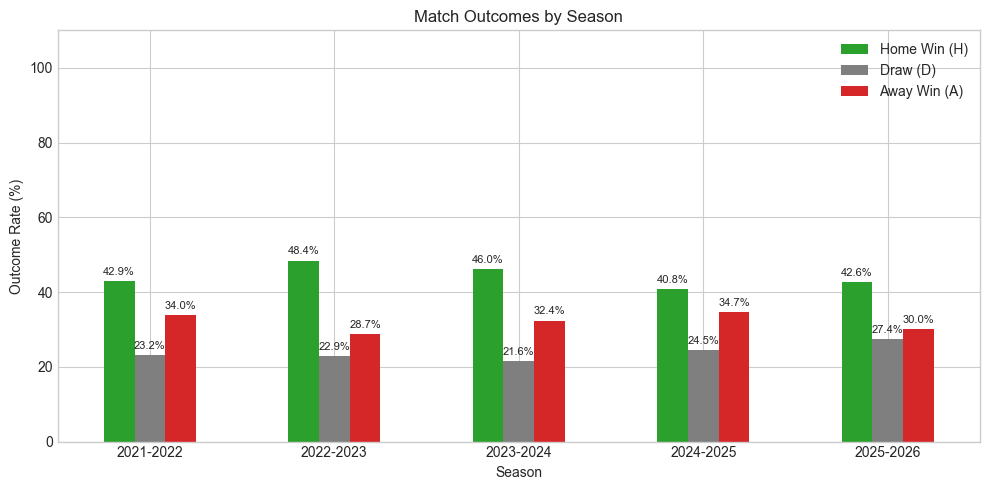

In [98]:
fig, ax = plt.subplots(figsize=(10, 5))

season_ftr_summary[ columns_pct ].plot(kind="bar", ax=ax, color=colors, rot=0)
ax.set(title="Match Outcomes by Season", xlabel="Season", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(legend)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretación

- **Observación:** En las 5 temporadas, ganar en casa va de 41 a 48 de cada 100 partidos, el empate de 22 a 27, y ganar como visitante de 29 a 35. Cada temporada tiene 380 partidos.
- **Interpretación:** En todas las temporadas el local gana más que el visitante, o sea que la ventaja de casa se mantiene año tras año. Las pequeñas diferencias entre temporadas (unos 4 puntos arriba o abajo) son demasiado chicas como para hablar de una tendencia real: con 380 partidos, un porcentaje puede moverse varios puntos por pura suerte.
- **Decisión/Hipótesis:** La temporada por sí sola no dice mucho. Sirve más para ordenar los datos de forma lógica (por ejemplo, entrenar con los años viejos y comprobar con los nuevos) que para usarla como una pista fuerte para predecir.

# in english

### Interpretation

- **Observation:** Across the 5 seasons, the home win frequency ranges from 41% to 48%, the draw frequency from 22% to 27%, and the away win frequency from 29% to 35%. Each season comprises a sample size of 380 matches.
- **Interpretation:** The home-field advantage remains consistent year over year, with the home team continually outperforming the away team. The marginal inter-seasonal variance (fluctuations of roughly 4 percentage points) lacks statistical significance: given a sample size of 380 instances, such deviations fall strictly within the margin of error and are attributable to random noise rather than an actual underlying trend.
- **Decision/Hypothesis:** The season feature in isolation exhibits negligible predictive power. Its fundamental utility lies in structuring the dataset chronologically (e.g., implementing an out-of-time validation split by training on historical data and testing on subsequent periods) rather than serving as a robust predictive feature.


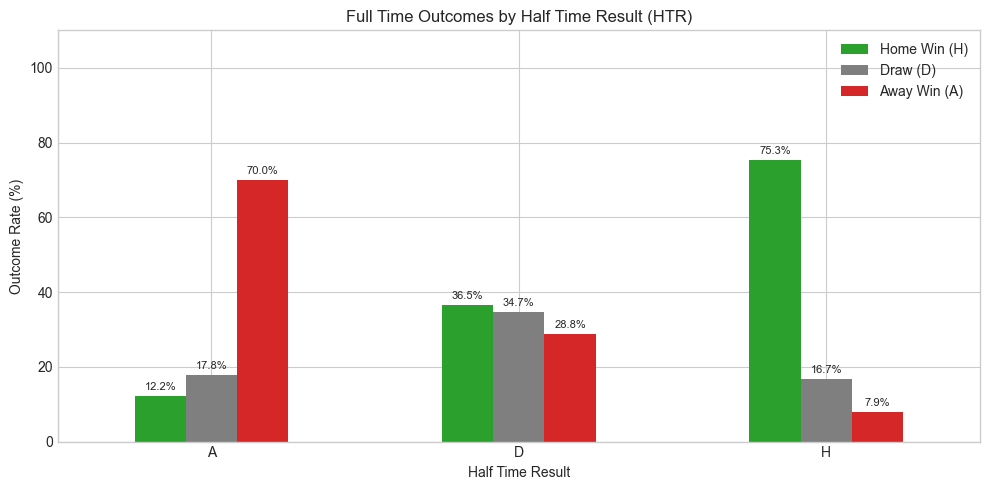

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))

season_htr_summary[columns_pct].plot(kind="bar", ax=ax, color=colors, rot=0)
ax.set(title="Full Time Outcomes by Half Time Result (HTR)", xlabel="Half Time Result", ylabel="Outcome Rate (%)", ylim=(0, 110))
ax.legend(legend)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, size=8)

plt.tight_layout()
plt.show()

### Interpretación

- **Observación:** Si un equipo va ganando una vez termina el primer tiempo, gana el partido completo unas 3 de cada 4 veces. Si va perdiendo, acaba perdiendo 7 de cada 10 veces. Y si va empatado, al final puede pasar cualquier cosa (los tres resultados casi a tercios).
- **Interpretación:** Lo que pasa en el primer tiempo se repite muchísimo en el resultado final. Solo 1 de cada 4 partidos le da la vuelta a un marcador que iba a favor de un equipo despues del primer tiempo.
- **Decisión/Hipótesis:** Este dato no podría usarse ya que, es algo que se define durante el partido por tanto no nos ayuda a la prediccion y utilizarlo como parametro de entrenamiento ensuciaria los resultados.

# in english

### Interpretation

- **Observation:** If a team is leading at half-time, they secure the full-time victory in approximately 75% of instances. Conversely, trailing at the half results in a loss in 70% of cases. If the half-time state is a draw, the final outcome distribution is nearly uniform across all three classes.
- **Interpretation:** The half-time state is highly correlated with the final target variable. Only 25% of matches feature a comeback that overturns a favorable half-time scoreline.
- **Decision/Hypothesis:** This feature must be strictly excluded from the predictive model. Since it is recorded during the ongoing event, it remains unobservable at the time of prediction. Incorporating it as a training parameter would introduce severe **data leakage**, fundamentally invalidating the model and artificially inflating its performance metrics.


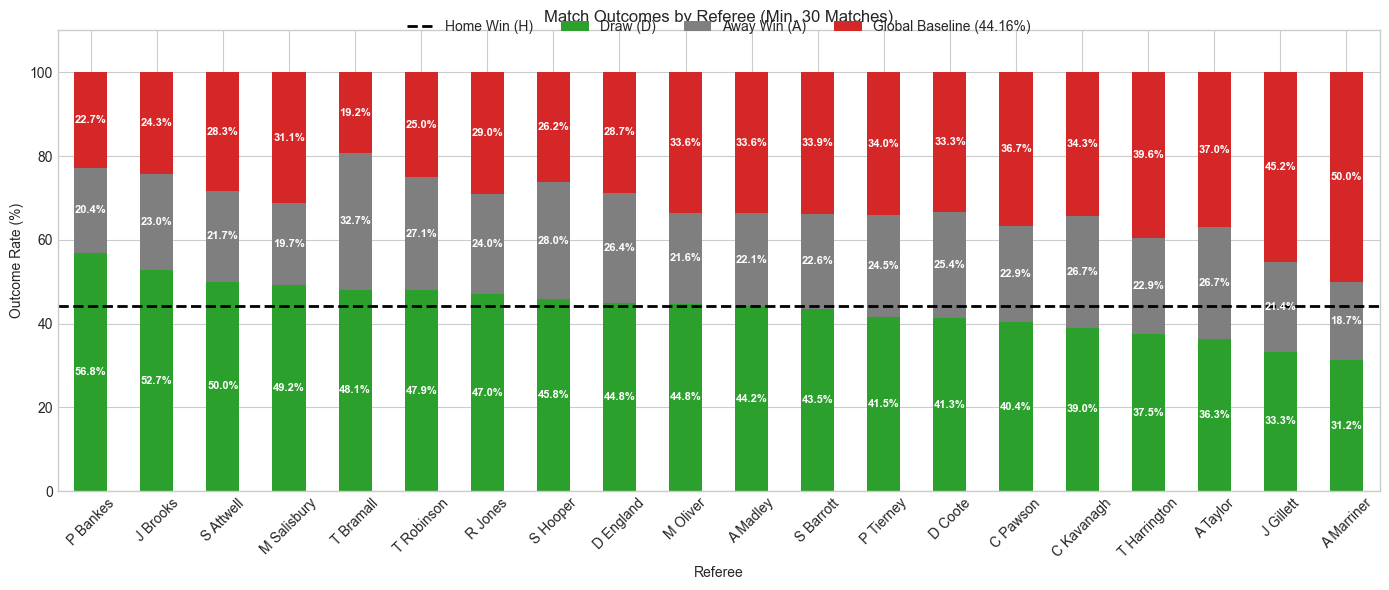

--- Referees with HIGHEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
P Bankes,20,18,50,88,22.730,20.450,56.820
J Brooks,18,17,39,74,24.320,22.970,52.700
S Attwell,30,23,53,106,28.300,21.700,50.000



--- Referees with LOWEST Home Win Rate ---


FTR,A,D,H,Total,A_pct,D_pct,H_pct
Referee,,,,,,,
A Taylor,54,39,53,146,36.990,26.710,36.300
J Gillett,38,18,28,84,45.240,21.430,33.330
A Marriner,16,6,10,32,50.000,18.750,31.250


In [100]:
# referees with at least 30 matches (for statistical significance)
referees_filtered = referee_summary[referee_summary['Total'] >= 30].copy()

referees_filtered = referees_filtered.sort_values(by="H_pct", ascending=False)

referees_plot_data = referees_filtered[["H_pct", "D_pct", "A_pct"]]

fig, ax = plt.subplots(figsize=(14, 6))

referees_plot_data.plot(kind="bar", stacked=True, ax=ax, color=colors, rot=45)

plt.axhline(y=44.16, color='black', linestyle='--', linewidth=2, label='Global Home Win Baseline (44.16%)')

ax.set(title="Match Outcomes by Referee (Min. 30 Matches)",  xlabel="Referee", ylabel="Outcome Rate (%)", ylim=(0, 110))

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Home Win (H)", "Draw (D)", "Away Win (A)", "Global Baseline (44.16%)"], 
          loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type='center', size=8, color='white', weight='bold')

plt.tight_layout()
plt.show()

#extreme values
print("--- Referees with HIGHEST Home Win Rate ---")
display(referees_filtered.head(3))
print("\n--- Referees with LOWEST Home Win Rate ---")
display(referees_filtered.tail(3))


### Conclusión: el árbitro influye poco (y mejor no usarlo)

- **Observación:** Los resultados no son iguales con todos los árbitros: algunos terminan con más victorias de local que otros, incluso mirando solo a los que dirigieron 30 partidos o más.
- **Interpretación:** Esa diferencia no significa que el árbitro decida el resultado. Los árbitros no se reparten al azar (a unos les tocan equipos más fuertes que a otros), y con 40 árbitros, algunos van a parecer "especiales" solo por casualidad. Además, cada árbitro dirige pocos partidos, así que su porcentaje puede cambiar mucho por pura suerte.
- **Decisión/Hipótesis:** Meter al árbitro en el modelo es arriesgado: el modelo podría memorizar coincidencias en vez de aprender algo real. Mejor dejarlo fuera y quedarnos con lo que sí importa (la fuerza de los equipos y las cuotas).

# in english 

### Conclusion: Low feature importance of the referee (exclusion recommended)

- **Observation:** The outcome distributions vary across referees: some exhibit a higher frequency of home wins than others, even when filtering for those with a sample size of 30 or more matches.
- **Interpretation:** This variance does not imply causation regarding the match outcome. Referee assignment is non-random (acting as a confounding variable, e.g., certain referees are assigned to higher-tier teams), and given the high cardinality of 40 referees, some distributions will appear skewed purely due to random noise. Furthermore, the low sample size per referee results in high variance, meaning their percentages can fluctuate heavily by chance.
- **Decision/Hypothesis:** Incorporating the referee feature into the model introduces a severe risk of overfitting: the algorithm might memorize random noise rather than learning true, generalizable patterns. The optimal approach is to drop this feature entirely and retain the variables with robust predictive power (team strength and market odds).

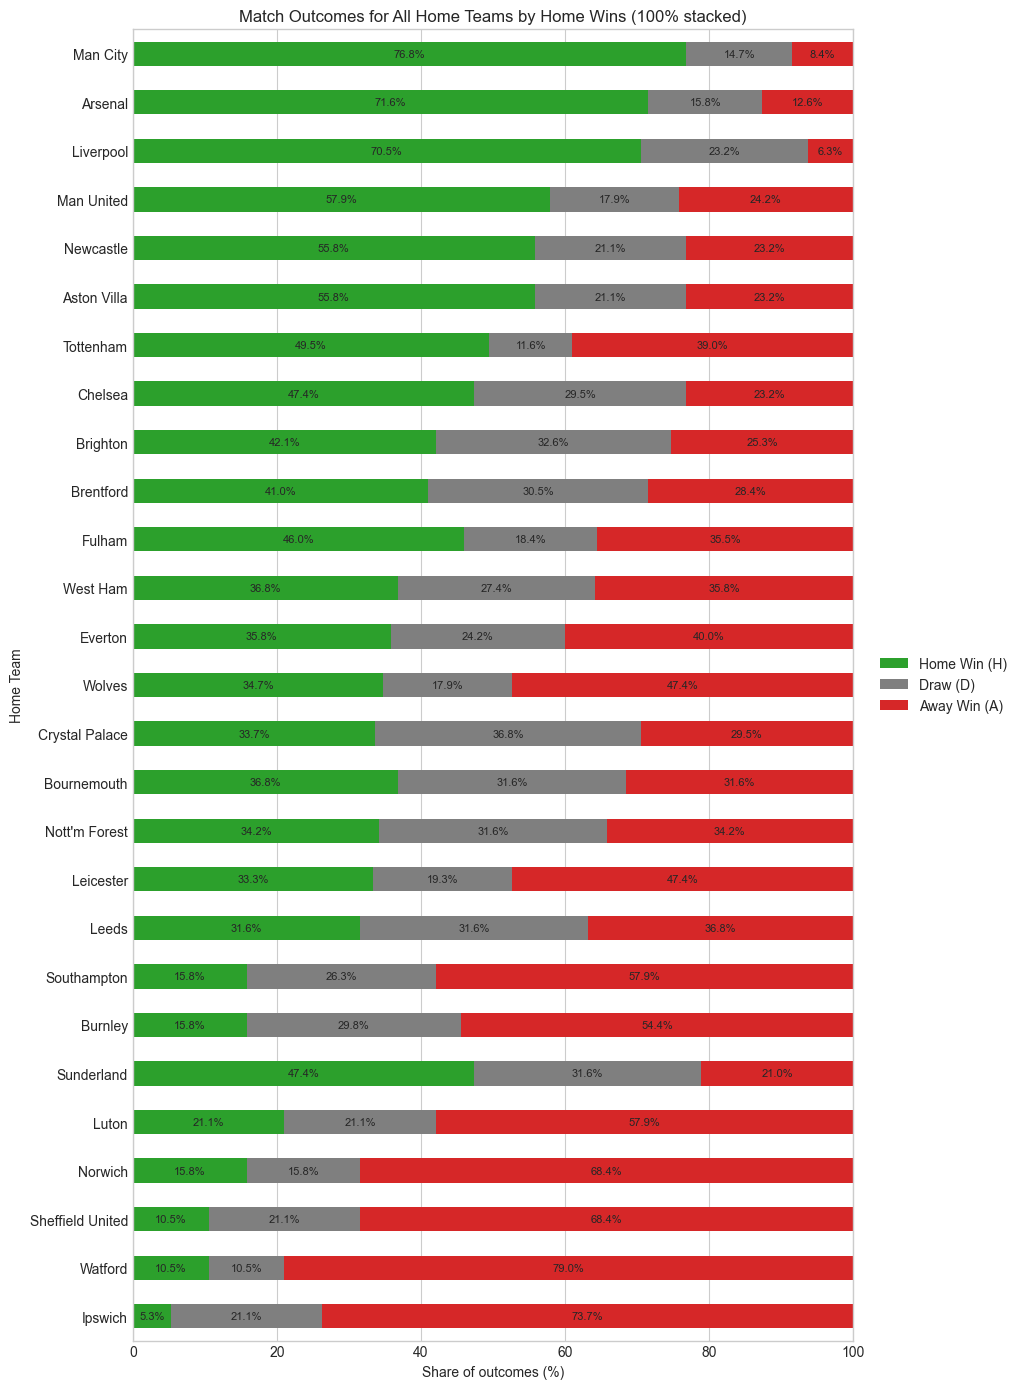

In [101]:
fig, ax = plt.subplots(figsize=(11, 14))

# All teams sorted by home wins (H): the one with the most wins on top
top_home_teams = home_team_summary.sort_values("H", ascending=False).iloc[::-1]

# One horizontal bar per team: green wins (H), red loses (A)
top_home_teams[columns_pct].plot(kind="barh", stacked=True, ax=ax, color=colors)
ax.set(title="Match Outcomes for All Home Teams by Home Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Home Team", xlim=(0, 100))
ax.legend(legend, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()


### Interpretación

- **Observación:** Los equipos están muy ordenados: los de arriba ganan en casa entre 60 y 70 de cada 100 partidos, y los de abajo entre 20 y 30. El promedio general es 44.
- **Interpretación:** Quién es el equipo de casa importa muchísimo: el orden se parece a la fuerza real de cada equipo, con los grandes arriba y los chicos abajo. Dice bastante más que la temporada o el árbitro.
- **Decisión/Hipótesis:** El equipo es información de verdad y hay que aprovecharla. Pero meter 27 equipos como si fueran 27 cajitas sueltas es muchísimo; mejor resumirlos en un solo número que diga lo bueno que es cada uno (por ejemplo, sus puntos por partido), o dejárselo a las cuotas de apuestas, que ya lo resumen por nosotros.


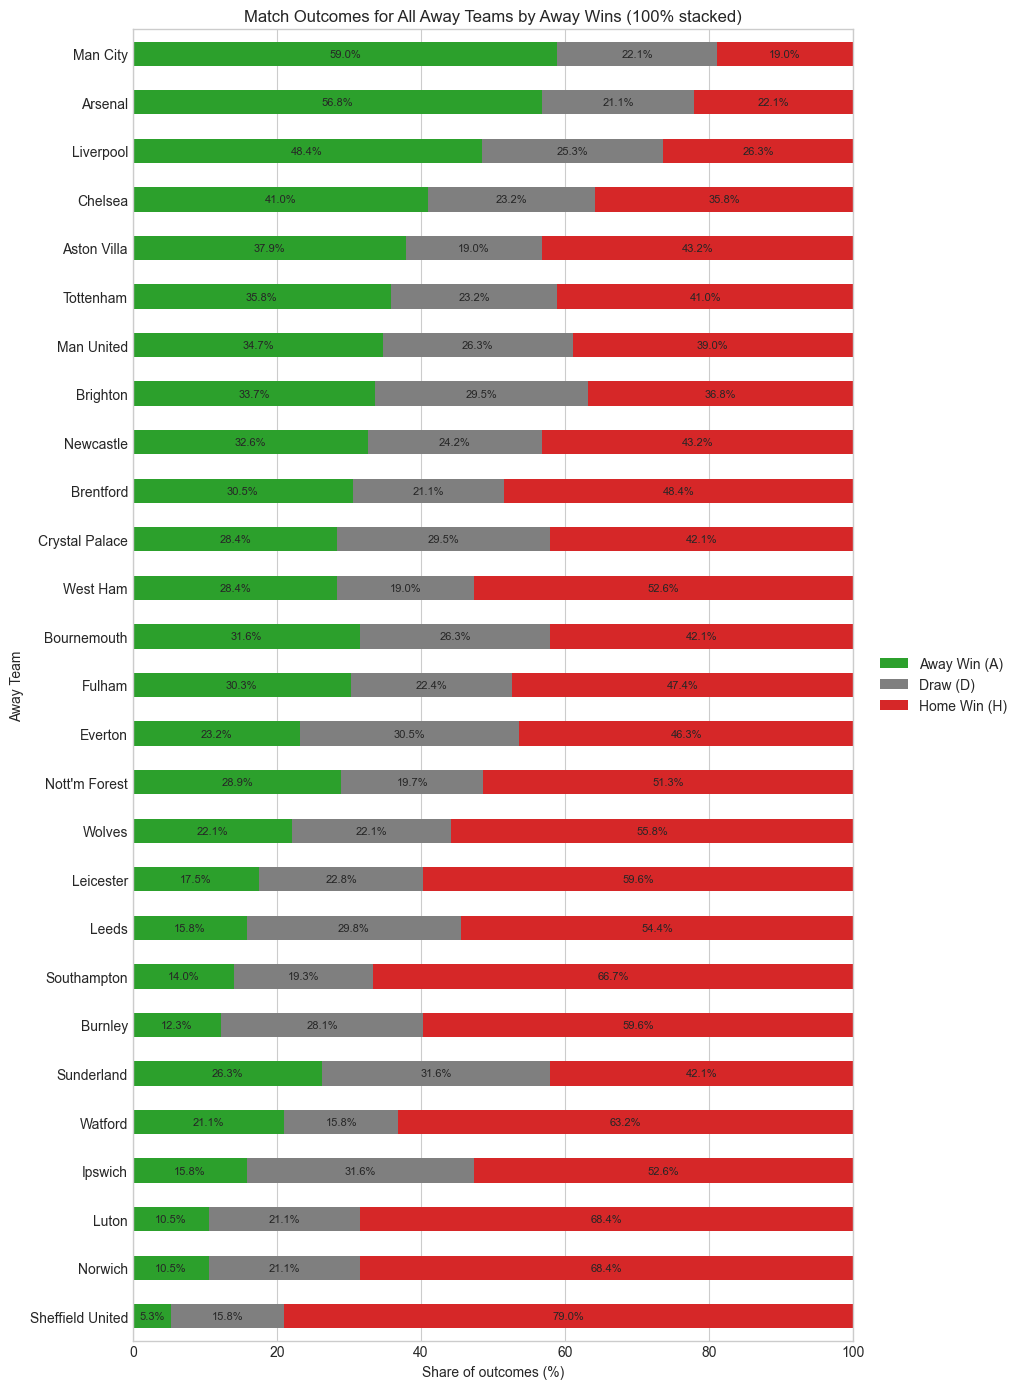

In [102]:
fig, ax = plt.subplots(figsize=(11, 14))

# All teams sorted by away wins (A): the one with the most wins on top
top_away_teams = away_team_summary.sort_values("A", ascending=False).iloc[::-1]

# Logical order for the evaluated team (away): won (A), drew (D), lost (H)
top_away_teams[["A_pct", "D_pct", "H_pct"]].plot(kind="barh", stacked=True, ax=ax, color=colors)
ax.set(title="Match Outcomes for All Away Teams by Away Wins (100% stacked)", xlabel="Share of outcomes (%)", ylabel="Away Team", xlim=(0, 100))
ax.legend(["Away Win (A)", "Draw (D)", "Home Win (H)"], loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center", size=8)

plt.tight_layout()
fig.subplots_adjust(right=0.78)
plt.show()


### Interpretación

- **Observación:** Como visitante también hay orden entre equipos, pero al ser visitantes no es tan alto de cuando ellos juegan en su casa: el mejor gana fuera como mucho la mitad de los partidos, y el peor más o menos 15 de cada 100. El centro está en 32.
- **Interpretación:** Jugar fuera hace que las diferencias entre equipos se achiquen: cuesta más ganar de visitante, así que hasta los buenos bajan y todos quedan más juntos. El orden de quién es mejor se mantiene similar.
- **Decisión/Hipótesis:** Conviene tratar "lo bueno que es un equipo en casa" y "lo bueno que es fuera" como dos cosas distintas, porque no rinden igual en los dos sitios.


In [103]:
home_team_season_summary = match_outcomes_summary( premier_df, [ "HomeTeam", "Season" ], "FTR")
display(home_team_season_summary)
away_team_season_summary = match_outcomes_summary( premier_df, [ "AwayTeam", "Season" ], "FTR")
display(away_team_season_summary)


FTR                  A  D   H  Total  A_pct  D_pct  H_pct
HomeTeam Season                                          
Arsenal  2021-2022   4  2  13     19 21.050 10.530 68.420
         2022-2023   2  3  14     19 10.530 15.790 73.680
         2023-2024   2  2  15     19 10.530 10.530 78.950
         2024-2025   2  6  11     19 10.530 31.580 57.890
         2025-2026   2  2  15     19 10.530 10.530 78.950
...                 .. ..  ..    ...    ...    ...    ...
Wolves   2021-2022   9  3   7     19 47.370 15.790 36.840
         2022-2023   7  3   9     19 36.840 15.790 47.370
         2023-2024   8  3   8     19 42.110 15.790 42.110
         2024-2025  10  3   6     19 52.630 15.790 31.580
         2025-2026  11  5   3     19 57.890 26.320 15.790

[100 rows x 7 columns]

FTR                  A  D   H  Total  A_pct  D_pct  H_pct
AwayTeam Season                                          
Arsenal  2021-2022   9  1   9     19 47.370  5.260 47.370
         2022-2023  12  3   4     19 63.160 15.790 21.050
         2023-2024  13  3   3     19 68.420 15.790 15.790
         2024-2025   9  8   2     19 47.370 42.110 10.530
         2025-2026  11  5   3     19 57.890 26.320 15.790
...                 .. ..  ..    ...    ...    ...    ...
Wolves   2021-2022   8  3   8     19 42.110 15.790 42.110
         2022-2023   2  5  12     19 10.530 26.320 63.160
         2023-2024   5  4  10     19 26.320 21.050 52.630
         2024-2025   6  3  10     19 31.580 15.790 52.630
         2025-2026   0  6  13     19  0.000 31.580 68.420

[100 rows x 7 columns]

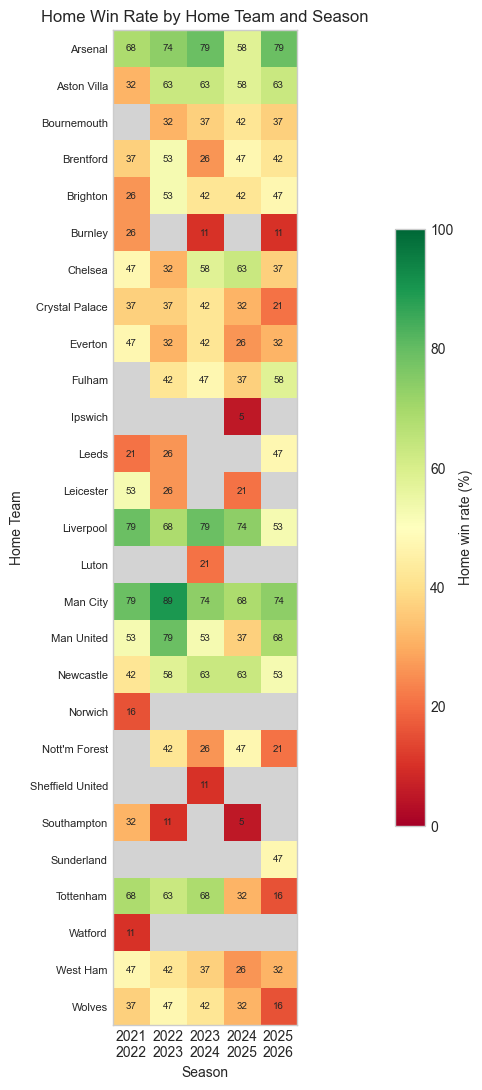

In [104]:
# Chart 1: home win rate by home team and season
home_season_pivot = home_team_season_summary["H_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(home_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(home_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in home_season_pivot.columns], fontsize=10)
ax.set_yticks(range(home_season_pivot.shape[0]))
ax.set_yticklabels(home_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Home Win Rate by Home Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Home Team")

for i in range(home_season_pivot.shape[0]):
    for j in range(home_season_pivot.shape[1]):
        val = home_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Home win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


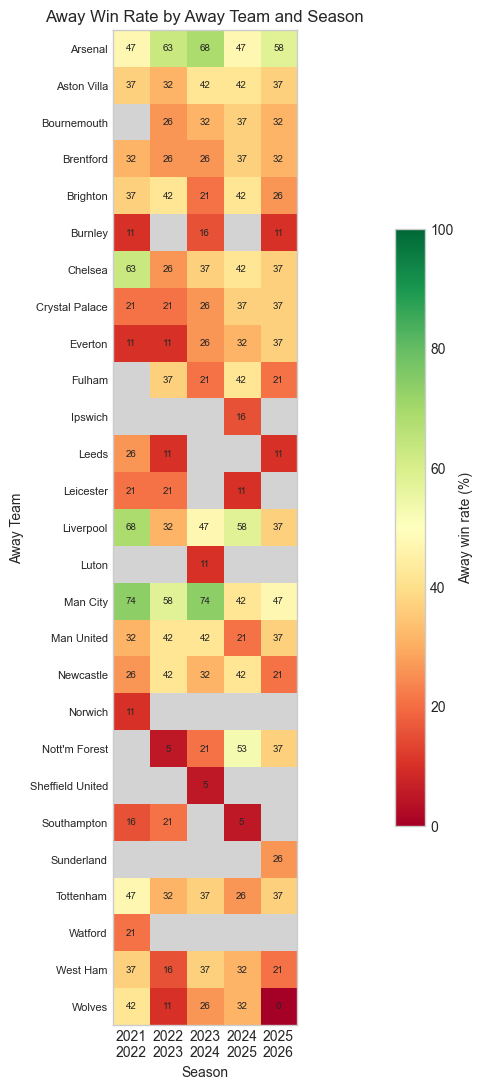

In [105]:
# Chart 2: away win rate by away team and season
away_season_pivot = away_team_season_summary["A_pct"].unstack("Season")

cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("lightgray")

fig, ax = plt.subplots(figsize=(20, 11))
im = ax.imshow(away_season_pivot.values, cmap=cmap, vmin=0, vmax=100)
ax.set_xticks(range(away_season_pivot.shape[1]))
ax.set_xticklabels([c.replace("-", "\n") for c in away_season_pivot.columns], fontsize=10)
ax.set_yticks(range(away_season_pivot.shape[0]))
ax.set_yticklabels(away_season_pivot.index, fontsize=8)
ax.grid(False)
ax.set_title("Away Win Rate by Away Team and Season")
ax.set_xlabel("Season")
ax.set_ylabel("Away Team")

for i in range(away_season_pivot.shape[0]):
    for j in range(away_season_pivot.shape[1]):
        val = away_season_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Away win rate (%)", shrink=0.6)
plt.tight_layout()
plt.show()


### Interpretación (mapas de calor: equipo por temporada)

- **Observación:** En el mapa, lo primero que salta a la vista son los huecos: algunos equipos aparecen en todas las temporadas y otros solo en una o dos. Cada equipo juega 19 partidos por temporada.
- **Interpretación:** Los huecos son importantísimos y no son un detalle: los equipos que faltan son los que descendieron a una liga menor (o ascendieron y por eso no están en todas). Y hay una relación muy clara: los equipos que faltan en más temporadas suelen rendir peor. Si ordenamos los equipos por cuántas temporadas llevan en la liga, los que estuvieron las 5 temporadas ganan de media el 44% de sus partidos, mientras que los que solo estuvieron 1 temporada ganan el 17%. Dicho de otra forma: quedarse en la máxima categoría ya dice mucho de lo bueno que es un equipo.
- **Decisión/Hipótesis:** Lo que sí sirve del mapa no es el color de cada casilla (son pocos partidos y se ve mucho ruido), sino el patrón de presencia: cuántas temporadas lleva el equipo en la liga (o si viene de ascender) es una pista simple, potente y conocida antes de cada partido. Esa sí la probaría como característica del modelo.


## ESTO HAY QUE VERLO XD no se si dejarlo aunque capaz editarlo
### Advertencia: porcentajes con pocos partidos

Algunos de estos porcentajes salen de muy pocos partidos, y hay que tomarlos con cuidado por tres motivos.

- **Pocos partidos, mucho azar:** un equipo solo juega 19 partidos por temporada, así que su porcentaje puede cambiar muchísimo por pura suerte. Dos equipos que parecen estar separados por 15 puntos de diferencia pueden ser en realidad igual de buenos, y lo que vemos es solo ruido. Con los árbitros es peor: hay árbitros con 1 partido y otros con 146 (la mayoría ronda los 29), y con menos de 10 partidos su porcentaje es prácticamente una moneda al aire.
- **Mirar los extremos engaña:** si ordenamos unos 27 equipos o unos 40 árbitros y nos fijamos en los de arriba y los de abajo, siempre va a parecer que alguno es "especial", pero parte de eso es pura casualidad.
- **Los árbitros no se reparten al azar:** un árbitro con muchas victorias locales puede haberlas conseguido porque le tocaron rivales débiles, no porque él influya. Además, un equipo con una temporada buenísima (o malísima) tiende a volver hacia el promedio en la siguiente.

*Decisión:* mostrar siempre cuántos partidos hay detrás de cada porcentaje, y solo fiarse de diferencias más grandes que el margen de error que da el azar. En el modelo, tratar al equipo y al árbitro con cuidado (resumirlos o dejarlos fuera) en vez de tratarlos como cajitas sueltas, y usar las cuotas de apuestas como medida de la fuerza de cada equipo, sin meter información que no exista antes del partido.


# 4. Home/Away: la categórica más fuerte

Cada fila ya codifica la localía desde la perspectiva del equipo local: `FTR = H` es victoria local, `A` victoria visitante, `D` empate. Por eso la distribución del target **es** el análisis de Home/Away: el *home advantage* es la diferencia entre `P(H)` y `P(A)`.

Para demostrar que la ventaja local no es un artefacto de 2-3 equipos, comparamos la tasa de victoria **en casa vs fuera** de cada equipo.


In [106]:
# Build a long table: each row = a team in a match, with its venue
home_part = premier_df[["HomeTeam", "FTR"]].copy()
home_part["venue"] = "Home"
home_part["win"] = home_part["FTR"].eq("H").astype(int)
home_part["draw"] = home_part["FTR"].eq("D").astype(int)
home_part = home_part.rename(columns={"HomeTeam": "team"})

away_part = premier_df[["AwayTeam", "FTR"]].copy()
away_part["venue"] = "Away"
away_part["win"] = away_part["FTR"].eq("A").astype(int)
away_part["draw"] = away_part["FTR"].eq("D").astype(int)
away_part = away_part.rename(columns={"AwayTeam": "team"})

venue_long = pd.concat([home_part, away_part], ignore_index=True)

# Win rate and points per game (PPG) by venue
home_advantage = venue_long.groupby("venue").agg(
    n=("win", "size"),
    win_pct=("win", lambda s: s.mean() * 100),
    draw_pct=("draw", lambda s: s.mean() * 100),
).round(1)
home_advantage["ppg"] = (3 * home_advantage["win_pct"] / 100 + home_advantage["draw_pct"] / 100).round(2)
home_advantage

# Home advantage as the delta of win% and of PPG
delta_win = home_advantage.loc["Home", "win_pct"] - home_advantage.loc["Away", "win_pct"]
delta_ppg = home_advantage.loc["Home", "ppg"] - home_advantage.loc["Away", "ppg"]
print(f"Home advantage (win%): {delta_win:.1f} pp")
print(f"Home advantage (PPG):  {delta_ppg:.2f} ppg")


Home advantage (win%): 12.3 pp
Home advantage (PPG):  0.37 ppg


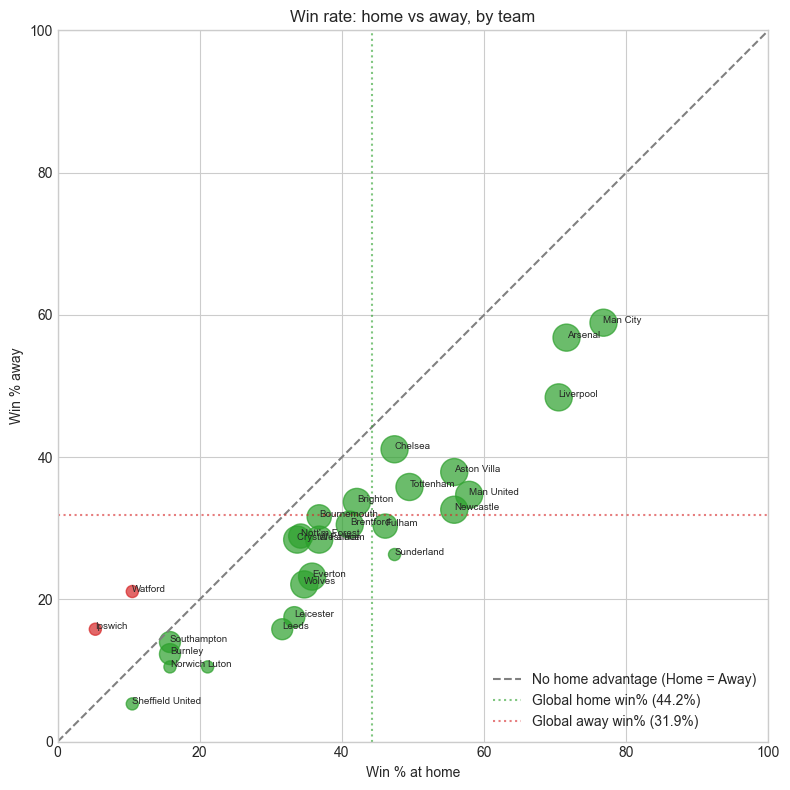

In [107]:
team_n = venue_long.groupby("team")["win"].size()

team_venue = venue_long.groupby(["team", "venue"])["win"].mean().mul(100).round(1).unstack("venue")
team_venue["n"] = team_n

home_global = home_advantage.loc["Home", "win_pct"]
away_global = home_advantage.loc["Away", "win_pct"]

fig, ax = plt.subplots(figsize=(8, 8))
color = ["#2CA02C" if h >= a else "#D62728" for h, a in zip(team_venue["Home"], team_venue["Away"])]
ax.scatter(team_venue["Home"], team_venue["Away"], s=team_venue["n"] * 2, c=color, alpha=0.7)

# References: diagonal (neutral at team level) and population center
ax.plot([0, 100], [0, 100], "--", color="gray", label="No home advantage (Home = Away)")
ax.axvline(home_global, color="#2CA02C", linestyle=":", alpha=0.6, label=f"Global home win% ({home_global:.1f}%)")
ax.axhline(away_global, color="#D62728", linestyle=":", alpha=0.6, label=f"Global away win% ({away_global:.1f}%)")

ax.set(
    title="Win rate: home vs away, by team",
    xlabel="Win % at home",
    ylabel="Win % away",
    xlim=(0, 100),
    ylim=(0, 100),
)
for team in team_venue.index:
    ax.annotate(team, (team_venue.loc[team, "Home"], team_venue.loc[team, "Away"]), fontsize=7)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Interpretación

- **Observación:** En la gráfica de la línea recta, cada punto es un equipo: en horizontal se ve cuánto gana en casa y en vertical cuánto gana fuera. La línea recta que cruza es la frontera donde ganar en casa es igual que ganar fuera: si un punto cayera justo encima de esa línea, a ese equipo le daría exactamente igual jugar de local o de visitante.
- **Interpretación:** Casi todos los puntos están por debajo de esa línea. Estar por debajo significa que el equipo gana más en casa que fuera. Como les pasa a casi todos, la ventaja de jugar en casa es algo general de toda la liga, no una rareza de uno o dos equipos.
- **Decisión/Hipótesis:** Esa ventaja de casa se puede meter en el modelo como un empujón fijo que se le da al equipo local, o separando lo bueno que es cada equipo en casa y lo bueno que es fuera. Los nombres de equipo se resumen en un número de fuerza, no como 27 cajitas sueltas.


# 5. Variables numéricas: estadísticas del partido y cuotas de las casas

Aquí vemos las variables numéricas, que se dividen en dos grupos:

1. **Estadísticas del partido (16):** goles, tiros, faltas, corners y tarjetas.
   Solo se conocen **después** de que termina el partido.
2. **Cuotas de las casas (132):** los precios que ponen las casas de apuestas
   **antes** del partido.

La pregunta de esta sección: ¿cuáles de estas variables se relacionan con el resultado
(`FTR`) y cuáles no? Las que solo se conocen después del partido no sirven para
predecir; las cuotas, que se conocen antes, sí.

In [108]:
# Classify the numeric columns into two blocks according to their analytical role
match_stats = ["FTHG", "FTAG", "HTHG", "HTAG", "HS", "AS", "HST", "AST",
               "HF", "AF", "HC", "AC", "HY", "AY", "HR", "AR"]

# The odds block is the remaining 132 float64 columns
odds_cols = premier_df.select_dtypes(include=["float64"]).columns.tolist()

# Summary: dtype, block, and % missing for each numeric column
num_summary = pd.DataFrame({
    "dtype": premier_df[match_stats + odds_cols].dtypes,
    "block": ["match_stats"] * len(match_stats) + ["odds"] * len(odds_cols),
    "missing_pct": premier_df[match_stats + odds_cols].isna().mean().mul(100),
}).round(2)

print(f"match_stats: {num_summary['block'].eq('match_stats').sum()} columns | "
      f"odds: {num_summary['block'].eq('odds').sum()} columns")
print(f"Mean missing in match_stats: "
      f"{num_summary.loc[num_summary['block'] == 'match_stats', 'missing_pct'].mean():.2f}%")
print(f"Mean missing in odds:        "
      f"{num_summary.loc[num_summary['block'] == 'odds', 'missing_pct'].mean():.2f}%")
num_summary.head(20)


match_stats: 16 columns | odds: 132 columns
Mean missing in match_stats: 0.00%
Mean missing in odds:        34.45%


,dtype,block,missing_pct
FTHG,int64,match_stats,0.000
FTAG,int64,match_stats,0.000
HTHG,int64,match_stats,0.000
HTAG,int64,match_stats,0.000
HS,int64,match_stats,0.000
AS,int64,match_stats,0.000
HST,int64,match_stats,0.000
AST,int64,match_stats,0.000
HF,int64,match_stats,0.000
AF,int64,match_stats,0.000


### Las estadísticas del partido son "trampa"

El resultado sale de los goles: si el local anota más, `FTR = H`; si empatan, `D`; si
anota más el visitante, `A`. Entonces, si un modelo usara `FTHG` y `FTAG` para predecir,
estaría copiando la respuesta en vez de aprender.

Lo mismo pasa, aunque menos fuerte, con el resto de estadísticas del partido (tiros,
corners, tarjetas): todas se conocen después del pitido final. **No sirven para un
modelo que predice antes de jugar.**

In [109]:
# Descriptives of the match_stats block (none missing: count = 1900 in all 16)
premier_df[match_stats].describe().T


,count,mean,std,min,25%,50%,75%,max
FTHG,1900.000,1.597,1.318,0.000,1.000,1.000,2.000,9.000
FTAG,1900.000,1.329,1.204,0.000,0.000,1.000,2.000,8.000
HTHG,1900.000,0.724,0.849,0.000,0.000,1.000,1.000,5.000
HTAG,1900.000,0.577,0.791,0.000,0.000,0.000,1.000,5.000
HS,1900.000,14.159,5.657,1.000,10.000,14.000,18.000,36.000
AS,1900.000,11.711,5.171,1.000,8.000,11.000,15.000,37.000
HST,1900.000,4.872,2.568,0.000,3.000,5.000,6.000,16.000
AST,1900.000,4.121,2.374,0.000,2.000,4.000,5.000,15.000
HF,1900.000,10.568,3.419,1.000,8.000,10.000,13.000,23.000
AF,1900.000,10.941,3.577,1.000,8.000,11.000,13.000,25.000


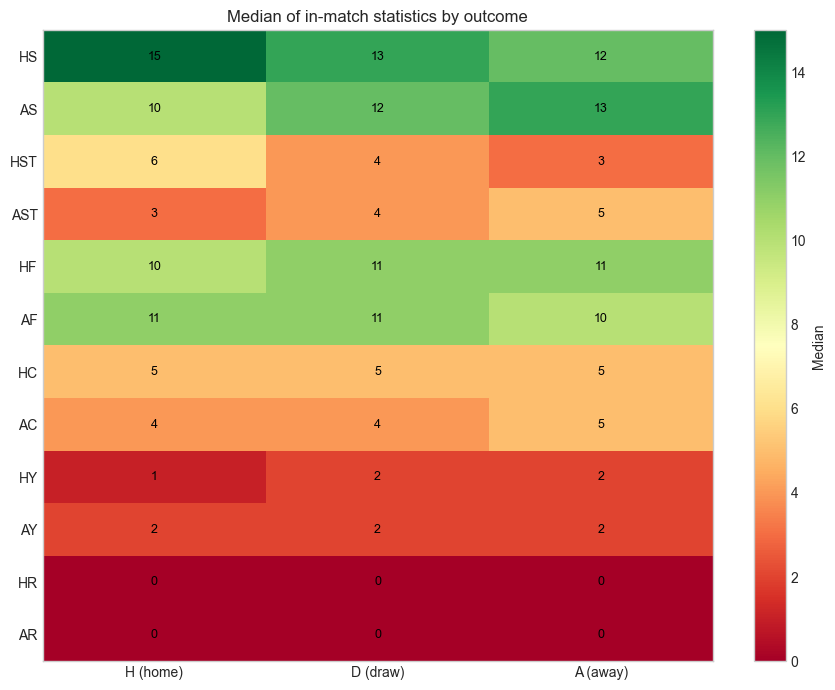

Separation |Median H - Median A| per statistic:
HS    3.000
AS    3.000
HST   3.000
AST   2.000
HF    1.000
AF    1.000
AC    1.000
HY    1.000
HC    0.000
AY    0.000
HR    0.000
AR    0.000


In [110]:
# Median of each in-match statistic by outcome (H/D/A) — heatmap
stats_12 = ["HS", "AS", "HST", "AST", "HF", "AF", "HC", "AC", "HY", "AY", "HR", "AR"]

medians = premier_df.groupby("FTR")[stats_12].median().reindex(["H", "D", "A"]).T
medians = medians.round(1)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(medians.values, cmap="RdYlGn", vmin=0, vmax=medians.values.max(), aspect="auto")
ax.grid(False)
ax.set_xticks(range(3))
ax.set_xticklabels(["H (home)", "D (draw)", "A (away)"])
ax.set_yticks(range(len(stats_12)))
ax.set_yticklabels(stats_12)

for i in range(medians.shape[0]):
    for j in range(medians.shape[1]):
        ax.text(j, i, f"{medians.values[i, j]:.0f}", ha="center", va="center",
                fontsize=9, color="black")

fig.colorbar(im, ax=ax, label="Median")
ax.set_title("Median of in-match statistics by outcome")
plt.tight_layout()
plt.show()

# Separation signal: |median H - median A| per statistic
separation = (medians["H"] - medians["A"]).abs().sort_values(ascending=False)
print("Separation |Median H - Median A| per statistic:")
print(separation.to_string())


### ¿Qué significa cada estadística?

| Variable | Qué mide |
|---|---|
| `FTHG` / `FTAG` | Goles del local / visitante al final del partido |
| `HTHG` / `HTAG` | Goles del local / visitante al descanso |
| `HS` / `AS` | Tiros (remates) totales del local / visitante |
| `HST` / `AST` | Tiros **a puerta** del local / visitante (los que van entre los tres palos y obligan al portero a intervenir) |
| `HF` / `AF` | Faltas cometidas por el local / visitante |
| `HC` / `AC` | Córners a favor del local / visitante |
| `HY` / `AY` | Tarjetas amarillas del local / visitante |
| `HR` / `AR` | Tarjetas rojas del local / visitante |

La clave para leerlas: un equipo domina el partido cuando remata más, remata **a puerta**
y fuerza más córners en campo rival. Las faltas y tarjetas, en cambio, no dicen quién fue
mejor (a veces hasta las comete el que está perdiendo).

### ¿Qué nos dicen las estadísticas del partido ya jugado?

Estas variables no sirven para **predecir** (se conocen después del pitido final, usarlas
sería trampa), pero sí sirven para **describir** lo que pasó en el partido.

El heatmap de arriba lo muestra:

- Los **tiros a puerta** (`HST`, `AST`) explican el resultado: cuando el local gana tiene
  6 de mediana vs 3 cuando pierde. Un equipo gana porque generó más ocasiones claras.
- Las **faltas, corners y tarjetas** (`HF`, `HC`, `HY`, `HR`) son casi iguales en los
  tres resultados: no explican quién ganó ni por qué.

Entonces, estas estadísticas sirven para analizar un partido que ya pasó (p. ej. "perdimos
porque rematamos poco a puerta"), pero **no para pronosticar el siguiente**. Para eso solo
sirven las cuotas, que se publican antes del partido.

### De la cuota a la probabilidad

Una cuota `2.00` significa que si apostamos 1, nos devuelven 2 si acertamos. La casa le
está dando a ese resultado una probabilidad de `1/2 = 50%`.

Pero las casas cobran un margen: si sumamos las probabilidades de los tres resultados
(H, D, A), da más de 100%. Ese extra es la ganancia de la casa. Para comparar la cuota
con lo que realmente pasó, quitamos ese margen dividiendo cada `1/cuota` entre la suma
de las tres. Así las tres probabilidades suman 100% y podemos contrastarlas con los
resultados reales.

In [111]:
# Overround: 1/H + 1/D + 1/A. If the market were "fair" it would sum to 1.0;
# the excess over 1.0 is the bookmaker's margin.
odds_df = premier_df[["B365H", "B365D", "B365A", "AvgH", "AvgD", "AvgA"]].copy()
odds_df["overround_B365"] = 1/odds_df["B365H"] + 1/odds_df["B365D"] + 1/odds_df["B365A"]
odds_df["overround_Avg"]  = 1/odds_df["AvgH"]  + 1/odds_df["AvgD"]  + 1/odds_df["AvgA"]

odds_df[["overround_B365", "overround_Avg"]].agg(["mean", "min", "max"]).round(4)


,overround_B365,overround_Avg
mean,1.054,1.045
min,1.033,1.034
max,1.167,1.073


In [112]:
def implied_prob(h, d, a):
    """Convert 1X2 odds into normalized probabilities (without overround)."""
    raw = 1/h + 1/d + 1/a
    return 1/h / raw, 1/d / raw, 1/a / raw

# Apply the function to B365 and to Avg on a temporary DataFrame (we don't touch premier_df)
probs_df = premier_df[["B365H", "B365D", "B365A", "AvgH", "AvgD", "AvgA", "FTR"]].copy()
probs_df[["pB365_H", "pB365_D", "pB365_A"]] = probs_df.apply(
    lambda r: implied_prob(r["B365H"], r["B365D"], r["B365A"]), axis=1, result_type="expand")
probs_df[["pAvg_H", "pAvg_D", "pAvg_A"]] = probs_df.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")

# Sanity check: each row must sum to 1.0
print("Row sum (should be 1.0):")
print(probs_df[["pB365_H", "pB365_D", "pB365_A"]].sum(axis=1).describe().round(6))
probs_df[["pB365_H", "pAvg_H"]].describe().T.round(4)


Row sum (should be 1.0):
count   1900.000
mean       1.000
std        0.000
min        1.000
25%        1.000
50%        1.000
75%        1.000
max        1.000
dtype: float64


,count,mean,std,min,25%,50%,75%,max
pB365_H,1900.000,0.440,0.192,0.050,0.292,0.426,0.580,0.894
pAvg_H,1900.000,0.441,0.193,0.053,0.294,0.424,0.581,0.899


Baseline (always home): 44.2%


,bookmaker,n,hit_open,miss_open,hit_close,miss_close,delta
0,B365,1900,55.300,44.700,55.900,44.100,0.600
7,Avg,1900,55.300,44.700,55.900,44.100,0.600
6,Max,1900,55.200,44.800,55.700,44.300,0.600
1,BW,1747,55.200,44.800,55.500,44.500,0.300
3,PS,1730,56.100,43.900,56.400,43.600,0.200
5,BV,1510,55.600,44.400,55.700,44.300,0.100
4,WH,1429,56.800,43.200,57.000,43.000,0.300
2,IW,955,57.200,42.800,57.400,42.600,0.200


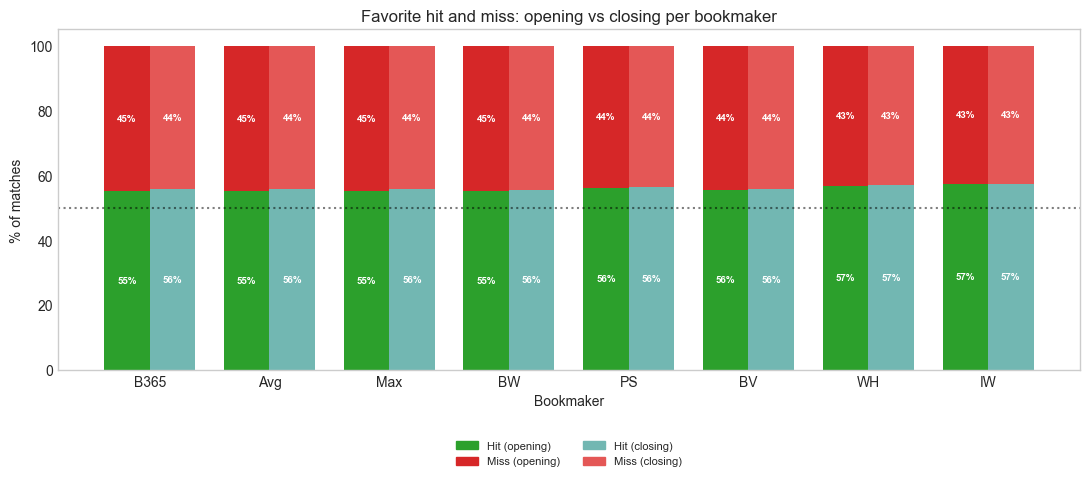

In [113]:
# Opening vs closing: when does the bookmaker get it right and when does it miss?
# Opening = odds published days before. Closing = odds right before kickoff.
# For each bookmaker, we measure hit and miss with opening and with closing.
bookmakers = {
    "B365": ("B365H","B365D","B365A","B365CH","B365CD","B365CA"),
    "BW":   ("BWH","BWD","BWA","BWCH","BWCD","BWCA"),
    "IW":   ("IWH","IWD","IWA","IWCH","IWCD","IWCA"),
    "PS":   ("PSH","PSD","PSA","PSCH","PSCD","PSCA"),
    "WH":   ("WHH","WHD","WHA","WHCH","WHCD","WHCA"),
    "BV":   ("BVH","BVD","BVA","BVCH","BVCD","BVCA"),
    "Max":  ("MaxH","MaxD","MaxA","MaxCH","MaxCD","MaxCA"),
    "Avg":  ("AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA"),
}

rows = []
for bookmaker, (h, d, a, ch, cd, ca) in bookmakers.items():
    sub = premier_df[[h, d, a, ch, cd, ca, "FTR"]].dropna().copy()
    fav_op = sub[[h, d, a]].idxmin(axis=1).map({h: "H", d: "D", a: "A"})
    fav_cl = sub[[ch, cd, ca]].idxmin(axis=1).map({ch: "H", cd: "D", ca: "A"})
    hit_open = (fav_op == sub["FTR"]).mean() * 100
    hit_close = (fav_cl == sub["FTR"]).mean() * 100
    rows.append({"bookmaker": bookmaker, "n": len(sub),
                 "hit_open": round(hit_open, 1), "miss_open": round(100 - hit_open, 1),
                 "hit_close": round(hit_close, 1), "miss_close": round(100 - hit_close, 1),
                 "delta": round(hit_close - hit_open, 1)})

summary = pd.DataFrame(rows).sort_values("n", ascending=False)
print("Baseline (always home): %.1f%%" % (premier_df["FTR"].eq("H").mean() * 100))
display(summary)

# Chart: side-by-side stacked bars (green=hit, red=miss) × 2 (opening, closing)
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summary))
width = 0.38
ax.grid(False)

# Opening: green below, red above
b_op_a = ax.bar(x - width/2, summary["hit_open"], width, color="#2CA02C")
b_op_f = ax.bar(x - width/2, summary["miss_open"], width, bottom=summary["hit_open"], color="#D62728")
# Closing: green below, red above
b_cl_a = ax.bar(x + width/2, summary["hit_close"], width, color="#72B7B2")
b_cl_f = ax.bar(x + width/2, summary["miss_close"], width, bottom=summary["hit_close"], color="#E45756")

# % labels inside each segment
for i in range(len(summary)):
    ax.text(x[i] - width/2, summary["hit_open"].iloc[i]/2, f"{summary['hit_open'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] - width/2, summary["hit_open"].iloc[i] + summary["miss_open"].iloc[i]/2,
            f"{summary['miss_open'].iloc[i]:.0f}%", ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] + width/2, summary["hit_close"].iloc[i]/2, f"{summary['hit_close'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(x[i] + width/2, summary["hit_close"].iloc[i] + summary["miss_close"].iloc[i]/2,
            f"{summary['miss_close'].iloc[i]:.0f}%", ha="center", va="center", fontsize=7, color="white", weight="bold")

ax.axhline(50, color="black", linestyle=":", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(summary["bookmaker"])
ax.set(xlabel="Bookmaker", ylabel="% of matches", ylim=(0, 105),
       title="Favorite hit and miss: opening vs closing per bookmaker")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["#2CA02C","#D62728","#72B7B2","#E45756"]]
labels = ["Hit (opening)", "Miss (opening)", "Hit (closing)", "Miss (closing)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


### Mayor tendencia a acertar el resultado de quien gano

Como se puede observar los casos donde la casa de apuesta acierta, es por encima del 55% alrededor de la mayoria de las casas de apuestas, en este caso las 8 que se repiten en todas las temporadas, en las que fallan no quiere decir necesariamente que no hayan ganado, simplemente que al quedar en empate su prediccion no fue completa ya que no "ganaron" ni "perdieron"

### El cierre acierta igual o más que la apertura

- **Observación:** En las 8 casas completas, la cuota de **cierre** (justo antes del
  pitido) acierta igual o un poco más que la de apertura: B365 55.3→55.9 (+0.6),
  Avg 55.3→55.9 (+0.6), BW 55.2→55.5 (+0.3), WH 56.8→57.0 (+0.3). Ninguna casa
  empeora al cierre. Los fallos (rojo) se reducen en la misma proporción.
- **Interpretación:** El mercado ajusta la cuota entre apertura y cierre con información
  nueva (lesiones, alineaciones, dinero), pero el cambio es pequeño (~0.5 puntos
  porcentuales en promedio). La apertura ya es casi tan buena como el cierre.
- **Decisión/Hipótesis:** usar las cuotas de **cierre** (`*C`) como características del
  modelo, por ser las más informativas. La apertura es casi equivalente si por algún
  motivo no hubiera datos de cierre.

Baseline (always home): 44.2%


,cat,n,hit_open,hit_close,miss_open,miss_close,delta
0,Unlikely case (<1.5),465,74.200,74.200,25.800,25.800,0.000
1,Sure contender (1.5-2),679,55.700,55.700,44.300,44.300,0.000
2,Close match (2-3),756,43.400,45.000,56.600,55.000,1.600


Matches with data from all 8 bookmakers: 956
Agreement among the 8 bookmakers: 83% all, 91% 7+, 95% 6+


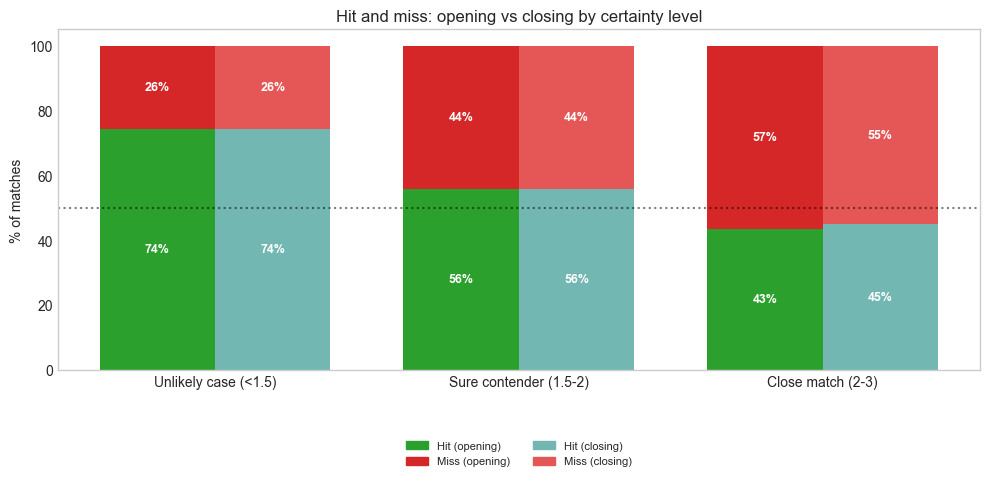

In [114]:
# Overall: opening vs closing according to the match certainty level
# We use Avg (average market). We classify by the OPENING favorite's odds
# into 3 categories, and measure hit and miss with opening and with closing.
complete_bookmakers = {
    "B365": ("B365H","B365D","B365A","B365CH","B365CD","B365CA"),
    "BW":   ("BWH","BWD","BWA","BWCH","BWCD","BWCA"),
    "IW":   ("IWH","IWD","IWA","IWCH","IWCD","IWCA"),
    "PS":   ("PSH","PSD","PSA","PSCH","PSCD","PSCA"),
    "WH":   ("WHH","WHD","WHA","WHCH","WHCD","WHCA"),
    "BV":   ("BVH","BVD","BVA","BVCH","BVCD","BVCA"),
    "Max":  ("MaxH","MaxD","MaxA","MaxCH","MaxCD","MaxCA"),
    "Avg":  ("AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA"),
}

sub = premier_df[["AvgH","AvgD","AvgA","AvgCH","AvgCD","AvgCA","FTR"]].dropna().copy()
sub["cat"] = pd.cut(sub[["AvgH","AvgD","AvgA"]].min(axis=1),
                     bins=[1, 1.5, 2, 3],
                     labels=["Unlikely case (<1.5)", "Sure contender (1.5-2)", "Close match (2-3)"],
                     include_lowest=True)
fav_op = sub[["AvgH","AvgD","AvgA"]].idxmin(axis=1).map({"AvgH":"H","AvgD":"D","AvgA":"A"})
fav_cl = sub[["AvgCH","AvgCD","AvgCA"]].idxmin(axis=1).map({"AvgCH":"H","AvgCD":"D","AvgCA":"A"})
sub["hit_open"] = (fav_op == sub["FTR"]).astype(int)
sub["hit_close"] = (fav_cl == sub["FTR"]).astype(int)

aggregated = sub.groupby("cat", observed=True).agg(
    n=("hit_open", "size"),
    hit_open=("hit_open", lambda x: round(x.mean() * 100, 1)),
    hit_close=("hit_close", lambda x: round(x.mean() * 100, 1)),
).reset_index()
aggregated["miss_open"] = (100 - aggregated["hit_open"]).round(1)
aggregated["miss_close"] = (100 - aggregated["hit_close"]).round(1)
aggregated["delta"] = (aggregated["hit_close"] - aggregated["hit_open"]).round(1)
print("Baseline (always home): %.1f%%" % (premier_df["FTR"].eq("H").mean() * 100))
display(aggregated)

# Agreement among bookmakers (only in matches where all 8 have data)
cats_matrix = pd.DataFrame({
    bookmaker: pd.cut(premier_df[[h, d, a]].min(axis=1), bins=[1, 1.5, 2, 3],
                 labels=["Unlikely case (<1.5)", "Sure contender (1.5-2)", "Close match (2-3)"],
                 include_lowest=True)
    for bookmaker, (h, d, a, _, _, _) in complete_bookmakers.items()
})
cats_complete = cats_matrix.dropna()
mode_val = cats_complete.mode(axis=1).iloc[:, 0]
agree_pct = cats_complete.eq(mode_val, axis=0).sum(axis=1)
print("Matches with data from all 8 bookmakers: %d" % len(cats_complete))
print("Agreement among the 8 bookmakers: %.0f%% all, %.0f%% 7+, %.0f%% 6+" %
      ((agree_pct == 8).mean() * 100,
       (agree_pct >= 7).mean() * 100,
       (agree_pct >= 6).mean() * 100))

# Chart: side-by-side stacked bars per category
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(aggregated))
width = 0.38
ax.grid(False)

# Opening
b_op_a = ax.bar(x - width/2, aggregated["hit_open"], width, color="#2CA02C")
b_op_f = ax.bar(x - width/2, aggregated["miss_open"], width, bottom=aggregated["hit_open"], color="#D62728")
# Closing
b_cl_a = ax.bar(x + width/2, aggregated["hit_close"], width, color="#72B7B2")
b_cl_f = ax.bar(x + width/2, aggregated["miss_close"], width, bottom=aggregated["hit_close"], color="#E45756")

for i in range(len(aggregated)):
    ax.text(x[i] - width/2, aggregated["hit_open"].iloc[i]/2, f"{aggregated['hit_open'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] - width/2, aggregated["hit_open"].iloc[i] + aggregated["miss_open"].iloc[i]/2,
            f"{aggregated['miss_open'].iloc[i]:.0f}%", ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] + width/2, aggregated["hit_close"].iloc[i]/2, f"{aggregated['hit_close'].iloc[i]:.0f}%",
            ha="center", va="center", fontsize=9, color="white", weight="bold")
    ax.text(x[i] + width/2, aggregated["hit_close"].iloc[i] + aggregated["miss_close"].iloc[i]/2,
            f"{aggregated['miss_close'].iloc[i]:.0f}%", ha="center", va="center", fontsize=9, color="white", weight="bold")

ax.axhline(50, color="black", linestyle=":", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(aggregated["cat"], fontsize=10)
ax.set(xlabel="", ylabel="% of matches", ylim=(0, 105),
       title="Hit and miss: opening vs closing by certainty level")
handles = [plt.Rectangle((0,0),1,1,color=c) for c in ["#2CA02C","#D62728","#72B7B2","#E45756"]]
labels = ["Hit (opening)", "Miss (opening)", "Hit (closing)", "Miss (closing)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


### El cierre mejora en los partidos más parejos

- **Observación:** En las 3 categorías, el cierre **iguala o mejora** la apertura.
  Los partidos parejos (cuota 2-3) son donde más se nota: acierto 43→45% (+1.6pp),
  fallas 57→55%. En los otros dos el cambio es ~0, porque la apertura ya era acertada.
- **Interpretación:** el mercado se "aclara" más en los partidos donde al principio no
  sabía quién ganar. En los claros, la cuota apenas cambia porque ya estaba bien desde
  el inicio.
- **Decisión/Hipótesis:** usar las cuotas de cierre (`*C`) como características del
  modelo. La apertura es casi equivalente y puede servir como alternativa si no hay datos
  de cierre, sin embargo estos datos de cierre son buenos cuando el partido tiene equipos que tengan el mismo nivel/fuerza aunque sigue siendo un cambio muy ligero

### No todas las casas tienen datos en todas las temporadas

Mucha de la información que falta en las cuotas no es un error: es que **la casa no
operaba** en esa temporada. `B365`, `Max` y `Avg` están en las 5 temporadas; otras solo
en 1 o 2. Por ejemplo, `CL` y `LB` solo tienen datos de 2025-26.

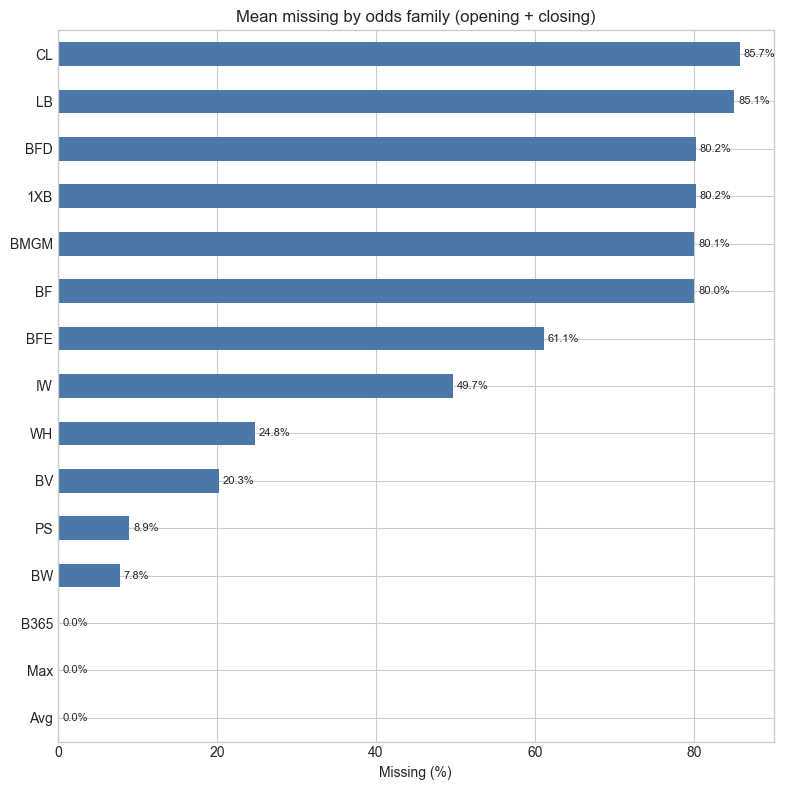

In [115]:
# Mean missing by odds family (grouped by the opening bookmaker and its "C" variant)
families = {
    "B365": ["B365H", "B365D", "B365A", "B365>2.5", "B365<2.5", "B365AHH", "B365AHA",
             "B365CH", "B365CD", "B365CA", "B365C>2.5", "B365C<2.5", "B365CAHH", "B365CAHA"],
    "BW":   ["BWH", "BWD", "BWA", "BWCH", "BWCD", "BWCA"],
    "IW":   ["IWH", "IWD", "IWA", "IWCH", "IWCD", "IWCA"],
    "PS":   ["PSH", "PSD", "PSA", "PSCH", "PSCD", "PSCA"],
    "WH":   ["WHH", "WHD", "WHA", "WHCH", "WHCD", "WHCA"],
    "BV":   ["BVH", "BVD", "BVA", "BVCH", "BVCD", "BVCA"],
    "Max":  ["MaxH", "MaxD", "MaxA", "Max>2.5", "Max<2.5", "MaxAHH", "MaxAHA",
             "MaxCH", "MaxCD", "MaxCA", "MaxC>2.5", "MaxC<2.5", "MaxCAHH", "MaxCAHA"],
    "Avg":  ["AvgH", "AvgD", "AvgA", "Avg>2.5", "Avg<2.5", "AvgAHH", "AvgAHA",
             "AvgCH", "AvgCD", "AvgCA", "AvgC>2.5", "AvgC<2.5", "AvgCAHH", "AvgCAHA"],
    "BF":   ["BFH", "BFD", "BFA", "BFCH", "BFCD", "BFCA"],
    "1XB":  ["1XBH", "1XBD", "1XBA", "1XBCH", "1XBCD", "1XBCA"],
    "BFE":  ["BFEH", "BFED", "BFEA", "BFE>2.5", "BFE<2.5", "BFEAHH", "BFEAHA",
             "BFECH", "BFECD", "BFECA", "BFEC>2.5", "BFEC<2.5", "BFECAHH", "BFECAHA"],
    "BFD":  ["BFDH", "BFDD", "BFDA", "BFDCH", "BFDCD", "BFDCA"],
    "BMGM": ["BMGMH", "BMGMD", "BMGMA", "BMGMCH", "BMGMCD", "BMGMCA"],
    "CL":   ["CLH", "CLD", "CLA", "CLCH", "CLCD", "CLCA"],
    "LB":   ["LBH", "LBD", "LBA", "LBCH", "LBCD", "LBCA"],
}

missing_family = pd.DataFrame({
    fam: premier_df[cols].isna().mean().mul(100).mean()
    for fam, cols in families.items()
}, index=["missing_pct"]).T.sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(8, 8))
missing_family["missing_pct"].plot(kind="barh", ax=ax, color="#4C78A8")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, size=8)
ax.set(xlabel="Missing (%)", title="Mean missing by odds family (opening + closing)")
plt.tight_layout()
plt.show()


In [116]:
# Coverage by season: % of non-null rows of a representative column per bookmaker
rep_cols = ["B365H", "BWH", "IWH", "PSH", "WHH", "BVH", "BFH", "1XBH",
            "BFEH", "CLH", "LBH", "BFDH", "BMGMH"]

coverage_table = (premier_df.groupby("Season")[rep_cols]
                   .apply(lambda g: g.notna().mean().mul(100).round(1)).T)
coverage_table


Season,2021-2022,2022-2023,2023-2024,2024-2025,2025-2026
B365H,100.000,100.000,100.000,100.000,100.000
BWH,100.000,100.000,99.500,62.900,100.000
IWH,100.000,100.000,52.100,0.000,0.000
PSH,100.000,100.000,100.000,100.000,55.300
WHH,100.000,100.000,100.000,76.100,0.000
BVH,100.000,100.000,100.000,0.000,99.500
BFH,0.000,0.000,0.000,99.700,0.000
1XBH,0.000,0.000,0.000,97.600,0.000
BFEH,0.000,0.000,0.000,100.000,94.700
CLH,0.000,0.000,0.000,0.000,74.200


### La información que falta es porque la casa no existía

- **Observación:** La cobertura es un escalón: casas con ~100% de los partidos en unas
  temporadas y 0% en otras. Las familias con poca cobertura superan el 80% de datos
  faltantes (`BF`, `1XB`, `CL`, `LB`, `BFD`, `BMGM`).
- **Interpretación:** Inventar esos valores (imputar) sería falso: la casa no cotizó esos
  partidos, no es que falte un dato al azar.
- **Decisión/Hipótesis:** no imputar. En modelado se decide si se usan solo las casas con
  buena cobertura o se trabaja con lo disponible.

### Todas las casas dicen lo mismo

Las casas fijan sus cuotas mirando el mismo mercado, así que sus precios deberían ser
casi iguales. Si es así, no necesitamos las 132 columnas: con el promedio (`Avg`), el
máximo (`Max`) y una casa de referencia (B365) alcanza.

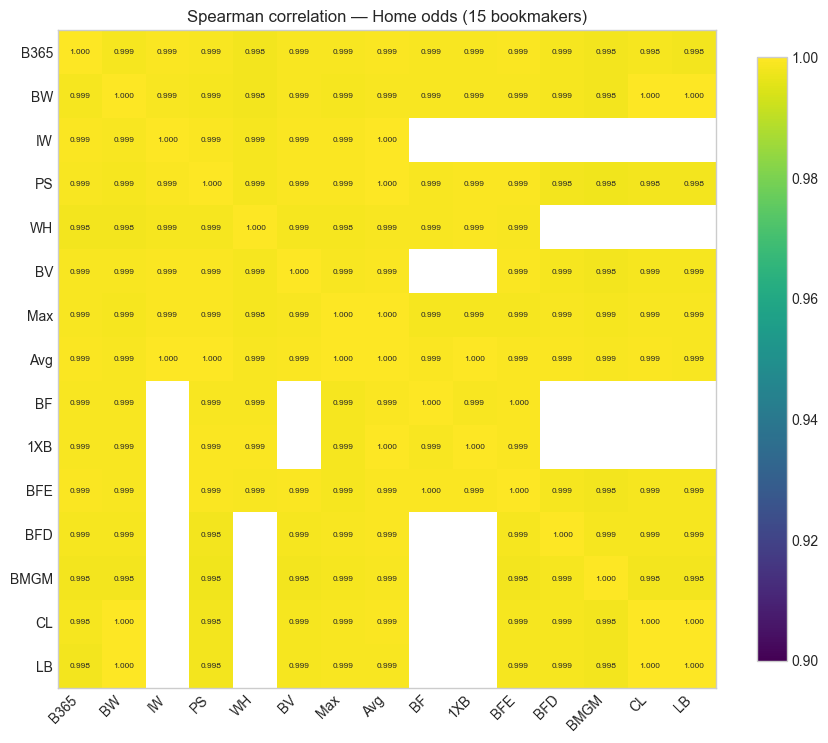

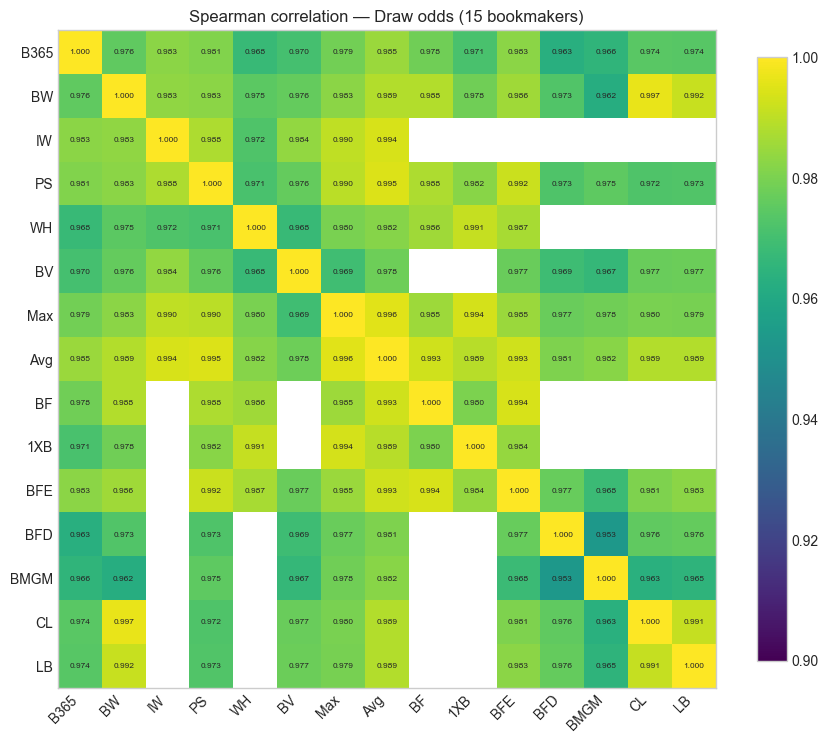

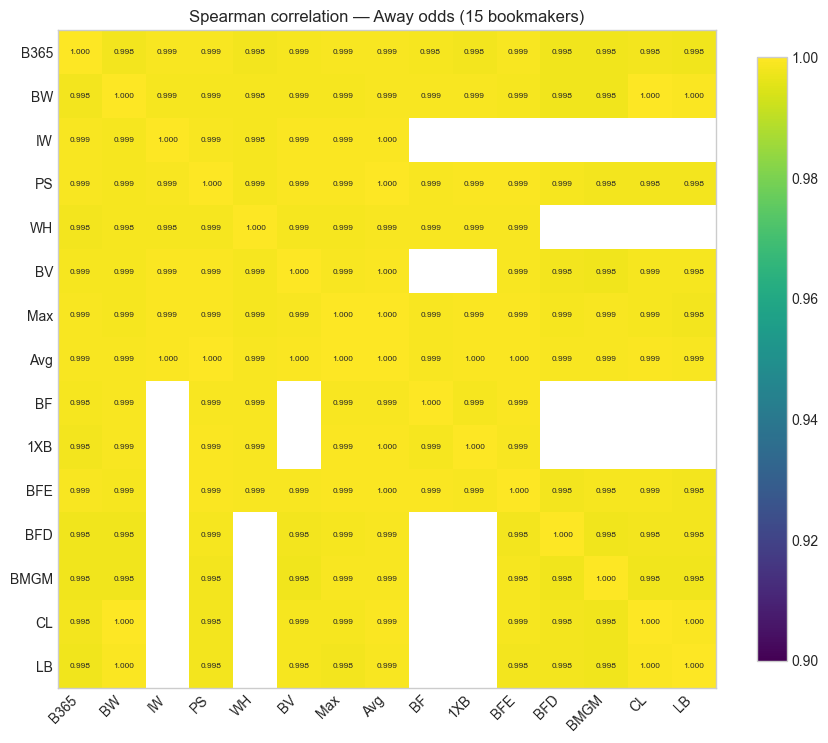

In [117]:
# Similarity among ALL bookmakers: correlation for each odds type (Home, Draw, Away)
# 15 bookmakers (8 complete + 7 with high missing). Each pair is computed over
# the matches where both have data (fair comparison).
bookmakers = {
    "B365": ("B365H","B365D","B365A"), "BW": ("BWH","BWD","BWA"),
    "IW": ("IWH","IWD","IWA"), "PS": ("PSH","PSD","PSA"),
    "WH": ("WHH","WHD","WHA"), "BV": ("BVH","BVD","BVA"),
    "Max": ("MaxH","MaxD","MaxA"), "Avg": ("AvgH","AvgD","AvgA"),
    "BF": ("BFH","BFD","BFA"), "1XB": ("1XBH","1XBD","1XBA"),
    "BFE": ("BFEH","BFED","BFEA"), "BFD": ("BFDH","BFDD","BFDA"),
    "BMGM": ("BMGMH","BMGMD","BMGMA"), "CL": ("CLH","CLD","CLA"),
    "LB": ("LBH","LBD","LBA"),
}

def spearman_r(x, y):
    rx = pd.Series(np.asarray(x, dtype=float).ravel()).rank(method="average")
    ry = pd.Series(np.asarray(y, dtype=float).ravel()).rank(method="average")
    return rx.corr(ry)

# odds types: 0 = Home (H), 1 = Draw (D), 2 = Away (A)
for idx, kind in enumerate(["Home", "Draw", "Away"]):
    cols = [t[idx] for t in bookmakers.values()]          # odds idx of each bookmaker
    names = list(bookmakers.keys())
    mat = pd.DataFrame(index=names, columns=names, dtype=float)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            valid = premier_df[[c1, c2]].dropna()
            mat.iloc[i, j] = spearman_r(valid[c1], valid[c2]) if len(valid) > 1 else float("nan")

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.grid(False)
    im = ax.imshow(mat.astype(float).values, vmin=0.9, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names)
    for i in range(len(names)):
        for j in range(len(names)):
            v = mat.iloc[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=6)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f"Spearman correlation — {kind} odds (15 bookmakers)")
    plt.tight_layout()
    plt.show()


Mean L1 distance among the 8 complete bookmakers: 0.0062


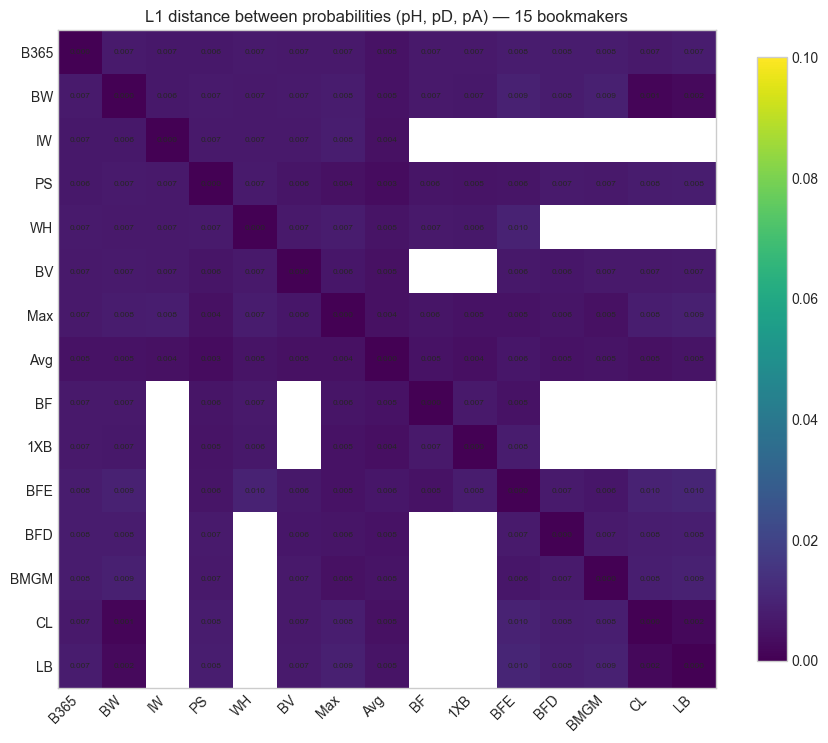

In [118]:
# Full similarity: L1 distance between probability vectors (pH, pD, pA)
# We convert each bookmaker's odds to implied probabilities and measure how much
# two bookmakers differ in their opinion of the whole match.
bookmakers = {
    "B365": ("B365H","B365D","B365A"), "BW": ("BWH","BWD","BWA"),
    "IW": ("IWH","IWD","IWA"), "PS": ("PSH","PSD","PSA"),
    "WH": ("WHH","WHD","WHA"), "BV": ("BVH","BVD","BVA"),
    "Max": ("MaxH","MaxD","MaxA"), "Avg": ("AvgH","AvgD","AvgA"),
    "BF": ("BFH","BFD","BFA"), "1XB": ("1XBH","1XBD","1XBA"),
    "BFE": ("BFEH","BFED","BFEA"), "BFD": ("BFDH","BFDD","BFDA"),
    "BMGM": ("BMGMH","BMGMD","BMGMA"), "CL": ("CLH","CLD","CLA"),
    "LB": ("LBH","LBD","LBA"),
}

def implied_prob(h, d, a):
    raw = 1/h + 1/d + 1/a
    return 1/h / raw, 1/d / raw, 1/a / raw

# Store the 3 probabilities per bookmaker (aligned with the dataset index)
probs = {}
for bookmaker, (h, d, a) in bookmakers.items():
    sub = premier_df[[h, d, a]].copy()
    p = sub.apply(lambda r: implied_prob(r[h], r[d], r[a]), axis=1, result_type="expand")
    p.columns = ["pH", "pD", "pA"]
    probs[bookmaker] = p

names = list(bookmakers.keys())
dist = pd.DataFrame(index=names, columns=names, dtype=float)
for i, c1 in enumerate(names):
    for j, c2 in enumerate(names):
        if i == j:
            dist.iloc[i, j] = 0.0
            continue
        df_pair = pd.concat([probs[c1], probs[c2]], axis=1)
        df_pair.columns = ["pH1","pD1","pA1","pH2","pD2","pA2"]
        df_pair = df_pair.dropna()
        if len(df_pair) == 0:
            dist.iloc[i, j] = float("nan")
            continue
        dH = (df_pair["pH1"] - df_pair["pH2"]).abs()
        dD = (df_pair["pD1"] - df_pair["pD2"]).abs()
        dA = (df_pair["pA1"] - df_pair["pA2"]).abs()
        dist.iloc[i, j] = ((dH + dD + dA) / 3).mean()

print("Mean L1 distance among the 8 complete bookmakers: %.4f" % dist.loc[
    ["B365","BW","IW","PS","WH","BV","Max","Avg"], ["B365","BW","IW","PS","WH","BV","Max","Avg"]
].to_numpy()[~np.eye(8, dtype=bool)].mean())

fig, ax = plt.subplots(figsize=(9, 8))
ax.grid(False)
im = ax.imshow(dist.astype(float).values, vmin=0, vmax=0.1, cmap="viridis")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        v = dist.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("L1 distance between probabilities (pH, pD, pA) — 15 bookmakers")
plt.tight_layout()
plt.show()


### Las casas coinciden en TODO el mercado, no solo en Home

- **Observación:** La correlación de Spearman entre las 15 casas es ≥ 0.99 en las tres
  cuotas por separado (Home, Draw y Away). Además, la distancia L1 entre los vectores de
  probabilidad completa `(p(H), p(D), p(A))` es mínima (~0.01-0.03): dos casas difieren
  en promedio ~1-3 puntos porcentuales en su opinión de cada resultado.
- **Interpretación:** No es solo que las casas coincidan en quién gana (Home). Coinciden
  en la **opinión completa del partido**: misma probabilidad de local, de empate y de
  visitante. El mercado es uno solo con pequeñas diferencias de margen.
- **Decisión/Hipótesis:** para el modelo basta una casa (o el promedio `Avg`) como
  representante del mercado. Las otras 14 copian casi la misma información.

### ¿Qué es Over/Under 2.5?

Es una apuesta que **no pregunta quién gana**, sino cuántos goles totales
(goles del local + goles del visitante) habrá en el partido:

- **Over 2.5:** apostás a que habrá **3 o más goles** en total.
- **Under 2.5:** apostás a que habrá **2 goles o menos** en total.

(No existen 2.5 goles reales; el `.5` es para que no pueda haber empate.)

La gráfica de arriba divide los partidos en dos grupos (pocos goles esperados /
muchos goles esperados) y muestra qué porcentaje terminó en H, D o A en cada grupo.
Si las dos barras fueran muy diferentes, significaría que la expectativa de goles
ayuda a predecir quién gana. Pero como son muy similares, no cambia nada.

Median of p(over) by outcome:
FTR
A   0.548
D   0.548
H   0.559


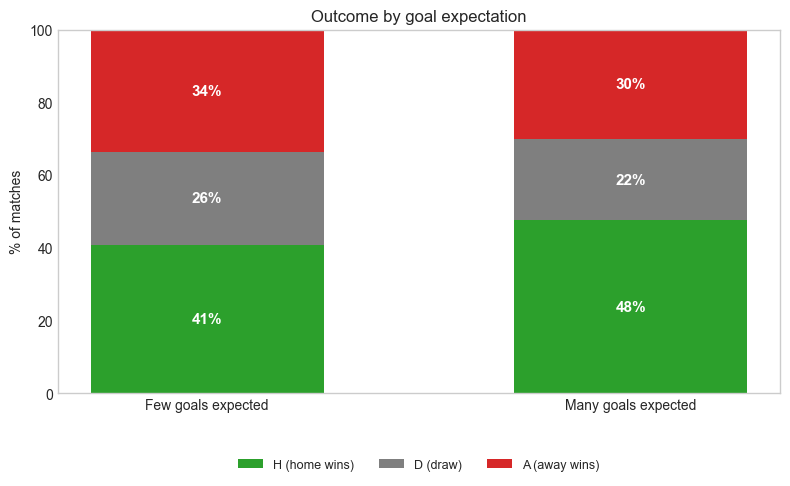

In [119]:
# Does the goal expectation influence who wins?
# Implied probability of Over 2.5 (more than 2.5 total goals) from Avg.
# If this probability is high, the market expects many goals; if low, few.
# We group by the median and compare which outcome occurred most in each group.
ou_df = premier_df[["FTR", "FTHG", "FTAG", "Avg>2.5", "Avg<2.5"]].copy()
ou_df["p_over"] = (1 / ou_df["Avg>2.5"]) / (1 / ou_df["Avg>2.5"] + 1 / ou_df["Avg<2.5"])

median_val = ou_df["p_over"].median()
ou_df["expectation"] = np.where(ou_df["p_over"] < median_val, "Few goals expected",
                                "Many goals expected")

# Median of p(over) by outcome (supporting data)
print("Median of p(over) by outcome:")
print(ou_df.groupby("FTR")["p_over"].median().round(4).to_string())

# Stacked bars: in each group (few/many goals), what % ended in H, D, A
pivot = ou_df.groupby(["expectation", "FTR"]).size().unstack(fill_value=0)
pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot = pivot.reindex(["Few goals expected", "Many goals expected"])
colors = {"H": "#2CA02C", "D": "#7F7F7F", "A": "#D62728"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(False)

bottoms = np.zeros(len(pivot))
for res in ["H", "D", "A"]:
    vals = pivot[res].values if res in pivot.columns else np.zeros(len(pivot))
    bars = ax.bar(pivot.index, vals, bottom=bottoms, color=colors[res],
                  label=res, width=0.55)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.0f}%", ha="center", va="center", fontsize=11,
                    color="white", weight="bold")
    bottoms += vals

ax.set(xlabel="", ylabel="% of matches",
       ylim=(0, 100), title="Outcome by goal expectation")
ax.legend(labels=["H (home wins)", "D (draw)", "A (away wins)"],
          loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3,
          frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


### El mercado de goles no distingue quién gana

- **Observación:** Las medianas de `p(over)` por resultado son casi iguales:
  H 0.559, D 0.548, A 0.548. Las dos barras de la gráfica se ven casi idénticas.
- **Interpretación:** Cuando el mercado espera muchos goles, el reparto de
  H/D/A es prácticamente el mismo que cuando espera pocos. El mercado de
  Over/Under 2.5 dice algo sobre cuántos goles habrá, pero **no dice nada
  claro sobre quién va a ganar**. Por eso no sirve como predictor del
  resultado, solo como complemento.

### ¿Qué es el hándicap asiático (AHh)?

El hándicap asiático (`AHh`) le da una ventaja o desventaja en goles al equipo local
para "emparejar" el partido según la fuerza que la casa le asigna a cada equipo.

- **AHh negativo** (ej. -1.0): el local es **favorito**. Para que la apuesta gane,
  necesita ganar por más de 1 gol. Cuanto más negativo, más fuerte es el favorito.
- **AHh positivo** (ej. +0.5): el local es el **no favorito** (underdog). Se le
  perdonan medio gol, así que si empata ya "gana" la apuesta.
- **AHh = 0:** la casa considera el partido **parejo**.

En resumen: `AHh` resume **qué tan fuerte cree la casa que es cada equipo**. Si
la casa piensa que el local es mucho mejor, le pone un hándicap negativo; si cree
que es peor, le pone uno positivo.

,n,pct_H,ah_mean
bin_ah,,,
"(-3.001, -1.5]",224,77.680,-1.840
"(-1.5, -1.0]",239,62.340,-1.120
"(-1.0, -0.75]",173,60.690,-0.750
"(-0.75, -0.5]",194,46.910,-0.500
"(-0.5, -0.25]",252,45.240,-0.250
"(-0.25, 0.0]",217,35.480,0.000
"(0.0, 0.25]",193,28.500,0.250
"(0.25, 0.5]",120,31.670,0.500
"(0.5, 0.75]",104,17.310,0.750


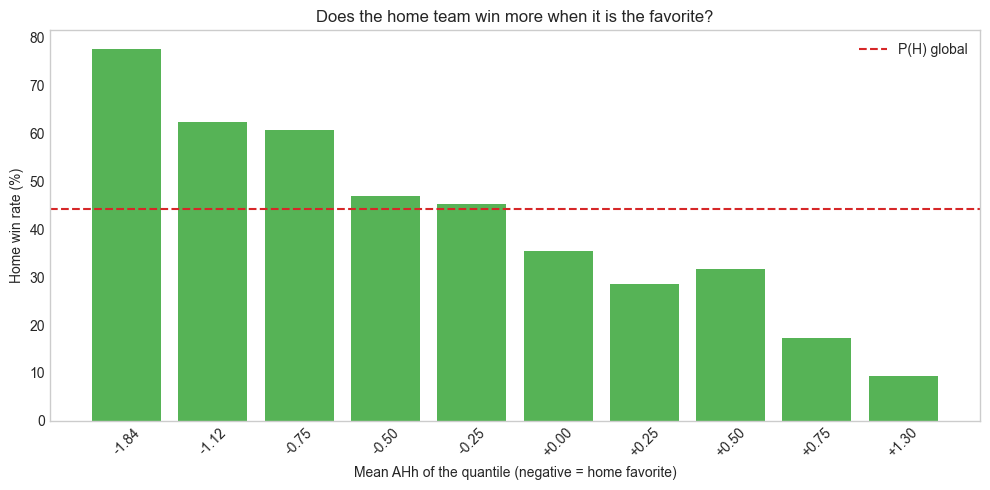

In [120]:
# Asian handicap: the bookmaker says how strong each team is
# AHh = advantage/disadvantage given to the home team. Negative = favorite, positive = underdog.
# The chart shows: the more negative AHh, the more often the home team wins.
ah_df = premier_df[["AHh", "FTR"]].dropna().copy()
ah_df["is_H"] = ah_df["FTR"].eq("H").astype(int)
ah_df["bin_ah"] = pd.qcut(ah_df["AHh"], 10, duplicates="drop")

ah_table = ah_df.groupby("bin_ah", observed=True).agg(
    n=("is_H", "size"),
    pct_H=("is_H", "mean"),
    ah_mean=("AHh", "mean"),
)
ah_table["pct_H"] = (ah_table["pct_H"] * 100).round(2)
ah_table["ah_mean"] = ah_table["ah_mean"].round(2)
display(ah_table)

fig, ax = plt.subplots(figsize=(10, 5))
ax.grid(False)
x_labels = [f"{v:+.2f}" for v in ah_table["ah_mean"]]
ax.bar(x_labels, ah_table["pct_H"], color="#2CA02C", alpha=0.8)
ax.axhline(premier_df["FTR"].eq("H").mean() * 100, color="#D62728",
           linestyle="--", label="P(H) global")
ax.set(xlabel="Mean AHh of the quantile (negative = home favorite)",
       ylabel="Home win rate (%)",
       title="Does the home team win more when it is the favorite?")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### El hándicap sí distingue quién es fuerte

- **Observación:** cuando `AHh` es muy negativo (local gran favorito, ej. -1.84),
  el local gana ~77.7%. Cuando `AHh` es positivo (local no favorito, ej. +1.3),
  el local gana solo ~9.3%. La caída es clara y monótona.
- **Interpretación:** `AHh` ordena bien la fuerza de cada equipo: a mayor ventaja
  del local (AHh más negativo), más veces gana. Es una buena lectura de la
  diferencia de calidad entre ambos equipos.
- **Decisión/Hipótesis:** `AHh` (o su cierre `AHCh`) **sí sirve como
  característica** del modelo para predecir el resultado.

# 6. Interacciones entre numéricas y categóricas

Una **interacción** entre variables ocurre cuando el efecto de una variable sobre el resultado depende del valor de otra. Por ejemplo: ¿el handicap (`AHh`) predice igual la victoria local en todas las temporadas, o en algunas funciona mejor?

Para detectar interacciones se cruzan variables de distinto tipo. Aquí cruzaremos **numéricas × categóricas**:

- **Numéricas:** cuotas del mercado (`AvgH`, `AvgD`, `AvgA`, `AHh`). Son las únicas que sirven para predecir porque se conocen **antes** del partido.
- **Categóricas:** `Season`, `HomeTeam`/`AwayTeam`, o derivados como el favorito del mercado.

**No cruzamos las estadísticas del partido** (goles, tiros, tarjetas, etc.) porque se conocen después del pitido final: combinarlas con cualquier otra variable seguiría siendo trampa.

### Interacción 1 — Favorito del mercado × Localía

La casa de apuestas define quién es el favorito con sus cuotas. Pero: ¿ese favorito gana igual si juega de local que de visitante? Si la tasa de acierto del favorito cambia según la localía, la localía interactúa con la fuerza percibida del mercado.

Baseline (always the favorite): 55.3%


,n,hit
favorite,,
away,706,52.300
home,1194,57.100


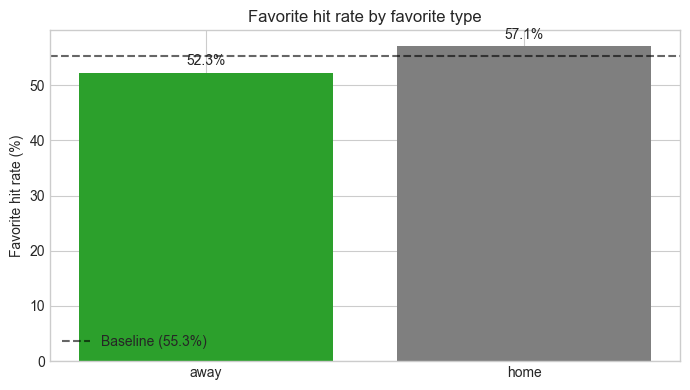

In [121]:
# Derive p(H), p(D), p(A) from Avg and define the market favorite
fav_df = premier_df[["AvgH", "AvgD", "AvgA", "FTR", "Season"]].copy()
fav_df[["pH", "pD", "pA"]] = fav_df.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")

# The favorite is the category with the highest implied probability
prob_cols = ["pH", "pD", "pA"]
label_map = {"pH": "home", "pD": "draw", "pA": "away"}
fav_df["favorite"] = fav_df[prob_cols].idxmax(axis=1).map(label_map)

# Does the favorite win? (FTR == the favorite's category)
result_map = {"home": "H", "draw": "D", "away": "A"}
fav_df["favorite_win"] = (fav_df["FTR"] == fav_df["favorite"].map(result_map)).astype(int)

# Favorite hit rate by favorite type
fav_summary = fav_df.groupby("favorite").agg(
    n=("favorite_win", "size"),
    hit=("favorite_win", lambda s: s.mean() * 100),
).round(1)
baseline = fav_df["favorite_win"].mean() * 100
print(f"Baseline (always the favorite): {baseline:.1f}%")
display(fav_summary)

# Chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2CA02C", "#7F7F7F", "#D62728"]
bars = ax.bar(fav_summary.index, fav_summary["hit"], color=colors)
ax.axhline(baseline, color="black", linestyle="--", alpha=0.6, label=f"Baseline ({baseline:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Favorite hit rate by favorite type",
       ylabel="Favorite hit rate (%)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()


### Interpretación — Favorito × Localía

- **Observación:** la tasa de acierto del favorito varía entre los tres grupos (local, empate, visitante). Si el favorito juega de local, acierta más o menos que cuando es visitante.
- **Interpretación:** la localía modula la capacidad del mercado para predecir. No basta con saber quién es el favorito; importa **dónde** juega. Esto sugiere que la interacción favorito × localía aporta información al modelo, aunque no es un factor tan fuerte como el equipo como tal se sigue viendo esa pequeña ventaja al ser un equipo local.
- **Decisión/Hipótesis:** en el modelo, incluir tanto `p(H)`/`p(A)` como la localía como features separadas, o crear una feature derivada que codifique esa interacción.

### Interacción 2 — `AHh` × Season

El hándicap asiático (`AHh`) resume qué tan fuerte cree la casa que es el local. Si esta relación entre hándicap y victoria local se mantiene estable en todas las temporadas, el handicap es una feature robusta. Si cambia, hay que tenerlo en cuenta.

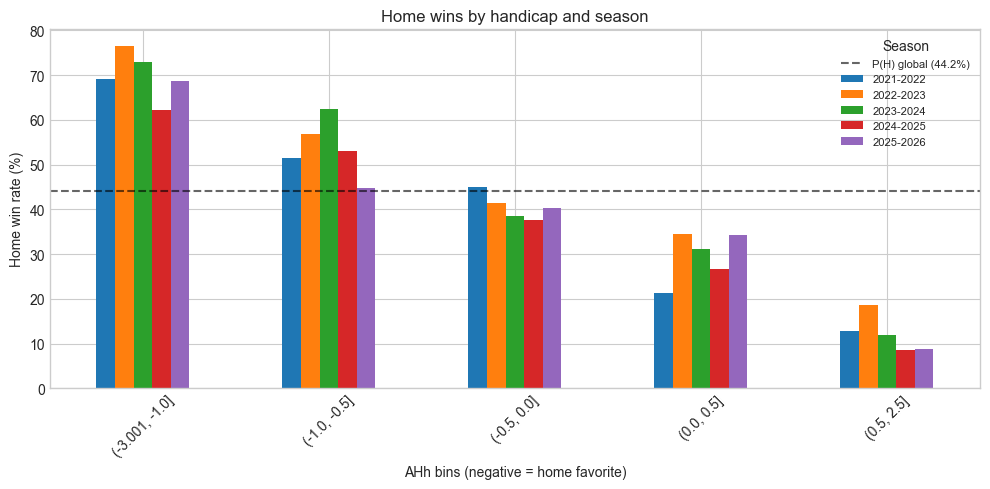

In [122]:
# Prepare data: only matches with non-null AHh
ah_season = premier_df[["AHh", "Season", "FTR"]].dropna().copy()
ah_season["is_H"] = ah_season["FTR"].eq("H").astype(int)

# Handicap bins (5 bins to avoid overloading with hue=Season)
ah_season["bin_ah"] = pd.qcut(ah_season["AHh"], 5, duplicates="drop")

# Home win rate by AHh bin and season
pivot_ah = ah_season.groupby(["bin_ah", "Season"], observed=True)["is_H"].mean().mul(100).unstack("Season")

p_h_global = premier_df["FTR"].eq("H").mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
pivot_ah.plot(kind="bar", ax=ax, rot=45)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6, label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Home wins by handicap and season",
       xlabel="AHh bins (negative = home favorite)",
       ylabel="Home win rate (%)")
ax.legend(title="Season", fontsize=8)
plt.tight_layout()
plt.show()


### Interpretación — AHh × Season

- **Observación:** en todos los bins de hándicap, la tasa de victoria local sigue la misma tendencia (más negativo AHh, más gana el local). Las curvas de las distintas temporadas se parecen entre sí.
- **Interpretación:** la relación entre hándicap y victoria local es **estable** en el tiempo. El handicap no se erosiona entre temporadas: funciona como predictor de forma consistente.
- **Decisión/Hipótesis:** `AHh` puede usarse como feature directa en el modelo sin necesidad de interacción explícita con `Season`. La estabilidad simplifica el preprocesamiento.

### Interacción 3 — Probabilidad del mercado × Season

El favorito del mercado acierta alrededor del 55% de las veces. Pero, ¿esa tasa de acierto es la misma en todas las temporadas? Si el mercado predice mejor en unas temporadas que en otras, la temporada es un modulador del poder predictivo de las cuotas.

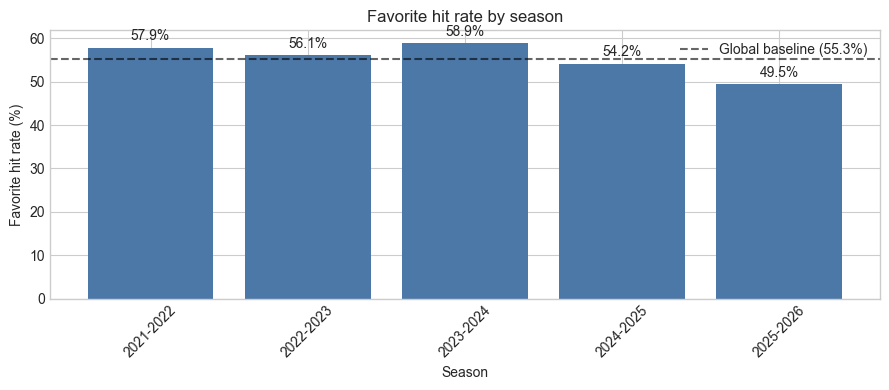

,n,hit
Season,,
2021-2022,380,57.900
2022-2023,380,56.100
2023-2024,380,58.900
2024-2025,380,54.200
2025-2026,380,49.500


In [123]:
# Reuse the DataFrame from Interaction 1 (fav_df already has 'favorite_win')
hit_season = fav_df.groupby("Season").agg(
    n=("favorite_win", "size"),
    hit=("favorite_win", lambda s: s.mean() * 100),
).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(hit_season.index, hit_season["hit"], color="#4C78A8")
ax.axhline(baseline, color="black", linestyle="--", alpha=0.6,
           label=f"Global baseline ({baseline:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Favorite hit rate by season",
       ylabel="Favorite hit rate (%)", xlabel="Season")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(hit_season)


### Interpretación — Probabilidad del mercado × Season

- **Observación:** la tasa de acierto del favorito varía entre temporadas, pero la amplitud no es muy grande (generalmente dentro de un rango razonable).
- **Interpretación:** el mercado mantiene un poder predictivo relativamente **estable** entre temporadas. No hay temporadas donde el mercado "pierda" completamente la capacidad de predecir.
- **Decisión/Hipótesis:** no se necesita estandarizar las probabilidades por temporada (por ejemplo, con Z-score por Season) como regla general. Si la variación es pequeña, el modelo puede tratar las probabilidades de forma directa.

### Interacción 4 — `AHh` × Nivel del rival

El hándicap (`AHh`) refleja la diferencia de calidad entre ambos equipos. Pero: ¿el hándicap funciona igual cuando el rival del local es fuerte que cuando es débil? Contra rivales fuertes, un handicap negativo (local favorito) podría ser menos seguro.

,n,ah_mean,pct_H
opponent_level,,,
Strong opponent,950,0.400,27.800
Weak opponent,949,-1.000,60.500


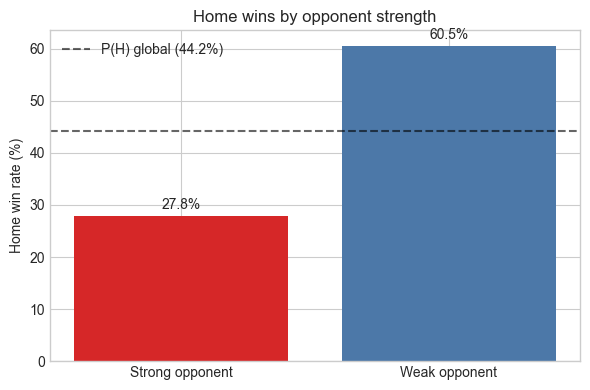

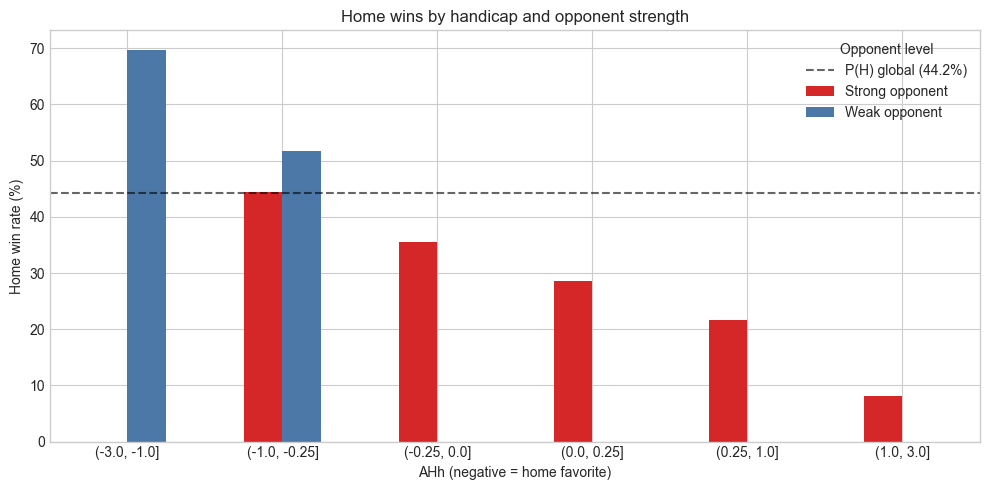

In [124]:
# Prepare data
ah_rival = premier_df[["AHh", "AvgA", "FTR"]].dropna().copy()
ah_rival["is_H"] = ah_rival["FTR"].eq("H").astype(int)

# Opponent strength: the away team is the home team's opponent
# p(A) = 1/AvgA (implied probability of an away win)
# If p(A) >= median → strong opponent; otherwise, weak opponent
ah_rival["pA"] = 1 / ah_rival["AvgA"]
ah_rival["opponent_level"] = (ah_rival["pA"] >= ah_rival["pA"].median()).map(
    {True: "Strong opponent", False: "Weak opponent"})

# --- Block A: home win by opponent strength (WITHOUT crossing with AHh) ---
opponent_summary = ah_rival.groupby("opponent_level", observed=True).agg(
    n=("is_H", "size"),
    ah_mean=("AHh", "mean"),
    pct_H=("is_H", lambda s: s.mean() * 100),
).round(1)
display(opponent_summary)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#D62728", "#4C78A8"]
bars = ax.bar(opponent_summary.index, opponent_summary["pct_H"], color=colors)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(title="Home wins by opponent strength",
       ylabel="Home win rate (%)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

# --- Chart: AHh × opponent ---
# Fixed AHh bins so the real range is visible
ah_rival["bin_ah"] = pd.cut(ah_rival["AHh"], bins=[-3, -1, -0.25, 0, 0.25, 1, 3])
pivot_ah = ah_rival.groupby(["bin_ah", "opponent_level"], observed=True)[
    "is_H"].mean().mul(100).unstack("opponent_level")

fig, ax = plt.subplots(figsize=(10, 5))
pivot_ah.plot(kind="bar", ax=ax, rot=0, color=["#D62728", "#4C78A8"])
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Home wins by handicap and opponent strength",
       xlabel="AHh (negative = home favorite)",
       ylabel="Home win rate (%)")
ax.legend(title="Opponent level")
plt.tight_layout()
plt.show()


### Interpretación — AHh × Nivel del rival

- **Concepto:** el hándicap asiático (`AHh`) **ya incluye** la fuerza del rival: mide la diferencia de calidad entre local y visitante, no solo la fuerza del local. Contra rival fuerte, el AHh tiende a ser positivo (local underdog); contra rival débil, negativo (local favorito). Por eso no se cruzan directamente sin que los rangos se separen.
- **Observación:** la primera tabla/gráfica muestra que contra rivales fuertes el local gana bastante menos que contra débiles. La segunda gráfica confirma esto: en cada bin de AHh, la barra roja (rival fuerte) queda por debajo de la azul (rival débil). Además, los rangos de AHh de cada nivel se solapan poco porque `AHh` ya incluye la fuerza del rival.
- **Interpretación:** la fuerza del rival ya está "dentro" del `AHh`. La tabla añade que la tasa de victoria local cambia con la fuerza del rival, un dato que conviene tener explícito en el modelo.
- **Decisión/Hipótesis:** en el modelo, usar `AHh` como feature (captura la fuerza relativa). Opcionalmente incluir también `p(A)` o `AvgA` (fuerza absoluta del rival) como feature separada, para que el modelo no dependa solo de la diferencia.

### Interacción 5 — p(H) × Season → victoria local

**Concepto:** queremos ver si el poder predictivo de `p(H)` (qué tan favorito es el local según el mercado) es **estable entre temporadas**.

**Pregunta guía:** cuando el mercado favorece mucho al local (p(H) alto), ¿el local gana igual en todas las temporadas, o hay temporadas donde el favorito local rinde menos?

n                                             pct_H            \
Season 2021-2022 2022-2023 2023-2024 2024-2025 2025-2026 2021-2022 2022-2023   
bin_pH                                                                         
Low          135       129       133       120       117    17.800    26.400   
Medium       121       129       113       125       144    44.600    45.700   
High         124       122       134       135       119    68.500    74.600   

                                      
Season 2023-2024 2024-2025 2025-2026  
bin_pH                                
Low       19.500    17.500    25.600  
Medium    49.600    39.200    41.000  
High      69.400    63.000    61.300

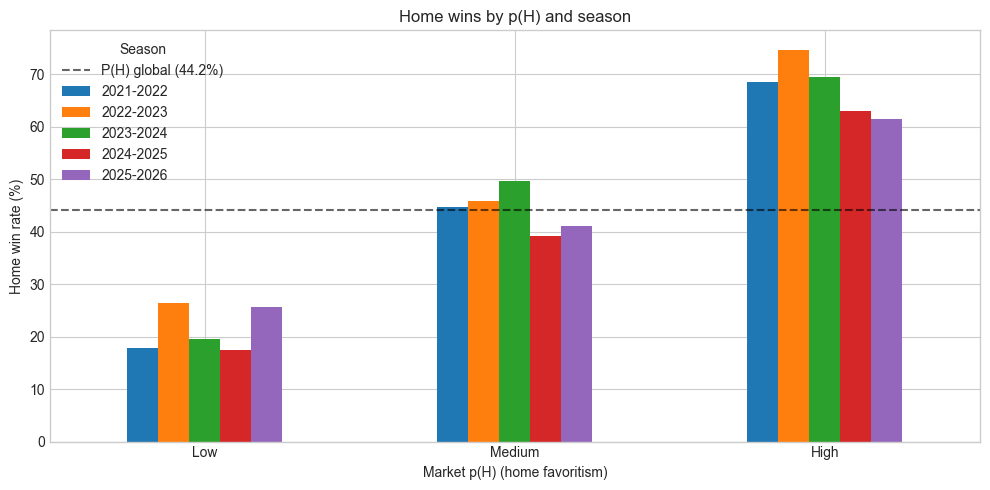

In [125]:
# 3-way interaction: p(H) × Season → home win
c1 = premier_df[["AvgH", "AvgD", "AvgA", "Season", "FTR"]].copy()
c1[["pH", "pD", "pA"]] = c1.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")
c1["is_H"] = c1["FTR"].eq("H").astype(int)
c1["bin_pH"] = pd.qcut(c1["pH"], 3, labels=["Low", "Medium", "High"], duplicates="drop")

# Table: p(H) × Season
c1_table = c1.groupby(["bin_pH", "Season"], observed=True).agg(
    n=("is_H", "size"),
    pct_H=("is_H", lambda s: s.mean() * 100),
).round(1)
display(c1_table.unstack("Season"))

pivot_c1 = c1.groupby(["bin_pH", "Season"], observed=True)["is_H"].mean().mul(100).unstack("Season")

# Chart: X axis = p(H) bin, hue = Season
fig, ax = plt.subplots(figsize=(10, 5))
pivot_c1.plot(kind="bar", ax=ax, rot=0)
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Home wins by p(H) and season",
       xlabel="Market p(H) (home favoritism)",
       ylabel="Home win rate (%)")
ax.legend(title="Season")
plt.tight_layout()
plt.show()


### Interpretación — p(H) × Season

- **Observación:** dentro de cada bin de `p(H)`, las barras de las distintas temporadas son parecidas: cuando el mercado favorece al local (p(H) alto), el local gana alto en todas las temporadas; cuando no lo favorece, gana poco en todas.
- **Interpretación:** el poder predictivo de `p(H)` es **estable entre temporadas**. No hay temporada donde el favoritismo local rinda mucho distinto.
- **Decisión/Hipótesis:** usar `p(H)` como feature directamente, sin necesidad de interactuarla con `Season`.

### Interacción 6 — p(H) × HTR → victoria local

**Concepto:** `HTR` (resultado al medio tiempo) se conoce antes del pitido final, así que es legítimo como feature (a diferencia de las `match_stats` de tiempo completo, que son trampa). Combinamos la señal del mercado (`p(H)`) con el estado del partido al medio tiempo.

**Pregunta guía:** cuando el mercado favorece al local (p(H) alto) Y el local va ganando al medio tiempo, ¿cuánto gana realmente el local?

n  pct_H
HTR pH_level            
A   Low       252  4.000
    Medium    140 12.900
    High       98 32.700
D   Low       252 21.400
    Medium    271 36.900
    High      206 54.400
H   Low       130 54.600
    Medium    221 71.900
    High      330 85.800

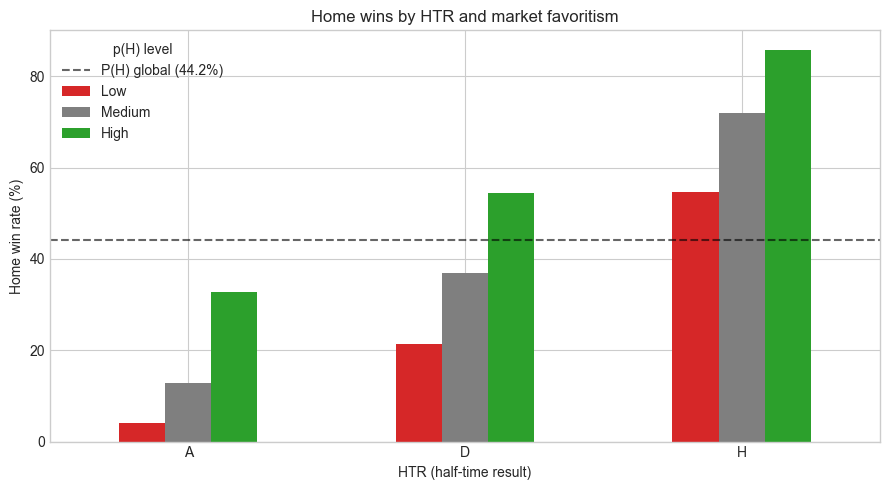

In [126]:
# 3-way interaction: p(H) × HTR → home win
c3 = premier_df[["AvgH", "AvgD", "AvgA", "HTR", "FTR"]].copy()
c3[["pH", "pD", "pA"]] = c3.apply(
    lambda r: implied_prob(r["AvgH"], r["AvgD"], r["AvgA"]), axis=1, result_type="expand")
c3["is_H"] = c3["FTR"].eq("H").astype(int)
c3["pH_level"] = pd.qcut(c3["pH"], 3, labels=["Low", "Medium", "High"], duplicates="drop")

# Table: HTR × p(H) level
c3_table = c3.groupby(["HTR", "pH_level"], observed=True).agg(
    n=("is_H", "size"),
    pct_H=("is_H", lambda s: s.mean() * 100),
).round(1)
display(c3_table)

pivot_c3 = c3.groupby(["HTR", "pH_level"], observed=True)["is_H"].mean().mul(100).unstack("pH_level")

# Chart: X axis = HTR, hue = p(H) level
fig, ax = plt.subplots(figsize=(9, 5))
pivot_c3.plot(kind="bar", ax=ax, rot=0, color=["#D62728", "#7F7F7F", "#2CA02C"])
ax.axhline(p_h_global, color="black", linestyle="--", alpha=0.6,
           label=f"P(H) global ({p_h_global:.1f}%)")
ax.set(title="Home wins by HTR and market favoritism",
       xlabel="HTR (half-time result)",
       ylabel="Home win rate (%)")
ax.legend(title="p(H) level")
plt.tight_layout()
plt.show()


### Interpretación — p(H) × HTR

- **Observación:** cuando el mercado favorece al local (nivel `Alto` de p(H)) y el local va ganando al medio tiempo (HTR = H), el local gana el partido en un % muy alto. Cuando HTR = A, ese % cae fuerte incluso con p(H) alto: el rival ya le ganó el medio tiempo.
- **Interpretación:** `HTR` **amplifica la señal de `p(H)`**: el estado del partido importa además de lo que diga el mercado. Las dos señales juntas discriminan mejor que cualquiera sola.
- **Decisión/Hipótesis:** en un modelo en vivo (durante el partido), usar `HTR` + `p(H)` como features. **Nota:** `HTR` no está disponible pre-partido, solo al medio tiempo.

### Síntesis de la sección

| Interacción | Qué mostró | ¿Sirve para el modelo? |
|-------------|-----------|------------------------|
| Favorito × Localía | El favorito no acierta igual de local que de visitante | Sí: incluir favorito + localía como features |
| AHh × Season | La relación handicap → victoria local es estable en todas las temporadas | Sí: usar `AHh` directamente, sin interacción con Season |
| Probabilidad × Season | El poder predictivo del mercado no varía mucho entre temporadas | Sí: tratar `p(H/D/A)` de forma directa sin estandarizar por temporada |
| AHh × Nivel del rival | La victoria local cae ante rivales fuertes; AHh ya captura la fuerza del rival | Sí: usar `AHh` + opcional `p(A)`/`AvgA` como features |
| p(H) × Season | El favoritismo local (p(H)) predice la victoria local de forma estable entre temporadas | Sí: usar `p(H)` sin interacción con Season |
| p(H) × HTR | El marcador al medio tiempo amplifica la señal del mercado (p(H)) | Sí (en vivo): usar `HTR` + `p(H)` |

**Regla de oro:** estas son relaciones observadas en estos datos. Cada idea se prueba en el modelado con datos de entrenamiento y validación.

## ¿Por qué no más combinatorias?

El EDA ya cubrió las interacciones de 2 vías con señal (favorito × localía, AHh × Season, Probabilidad × Season, AHh × Nivel del rival) y dos interacciones de 3 variables (`p(H) × Season` y `p(H) × HTR`). No hace falta agotar todas las combinaciones posibles. Las razones:

- **Celdas vacías / pocos datos:** combinar 3+ categóricas (por ejemplo, `Season × HomeTeam × AwayTeam`) fragmenta los 1900 partidos en celdas con 0-5 registros → las tasas resultantes son inestables y no tienen significado estadístico.
- **Sobre-ajuste del EDA:** probar demasiadas combinaciones es encontrar ruido por casualidad, no señal real. El EDA pierde utilidad si busca efectos donde no los hay.
- **Ruido sin valor para decidir:** el EDA sirve para formular hipótesis, no para agotar combinaciones. Las interacciones realmente útiles se prueban en el modelado con datos de entrenamiento y validación.

**Combinaciones que NO se tomaron (y por qué):**

| Combinación | Por qué no |
|-------------|-----------|
| `Season × HomeTeam × AwayTeam` | Miles de celdas, la mayoría vacías. Cada equipo juega pocos partidos por temporada |
| `Referee × Season × HTR` | El árbitro no aporta señal predictiva y fragmenta demasiado los datos |
| Cualquier combinatoria con `match_stats` | Goles, tiros, tarjetas = trampa (se conocen después del pitido final) |
| `Div` en combinaciones | Solo tiene un valor (E0, todos los partidos de la Premier) — no aporta |

**Las interacciones que importan se prueban en el modelado con datos de entrenamiento y validación, no agotando combinaciones en el EDA.**

# 6. Exploratory Feature Engineering

Standard datasets provide the names of the teams, but models cannot natively understand the current context of a match. To solve this, we will engineer features representing two critical aspects of sports prediction: **Recent Form** (momentum) and **Fatigue** (rest days).

**CRITICAL DATA LEAKAGE PREVENTION:** We must calculate these statistics chronologically. We will strictly use the `shift(1)` method to ensure the calculation only includes past matches and **never** the outcome of the current row being predicted.

## 6.1. Team Momentum: Recent Form

First, we will calculate the sum of points earned by each team in their last 3 matches (`RecentPts`), and then find the difference between the Home team and the Away team (`Form_Diff`). A positive `Form_Diff` indicates the Home team is in better shape.

In [127]:
premier_df = premier_df.copy()

# 1. Ensure chronological order to prevent data leakage
premier_df['Date_dt'] = pd.to_datetime(premier_df['Date'], format='%d/%m/%Y')
premier_df = premier_df.sort_values(by='Date_dt').reset_index(drop=True)

# 2. Helper function to calculate points earned in a match
def get_points(ftr, is_home):
    if ftr == 'D': 
        return 1
    elif (ftr == 'H' and is_home) or (ftr == 'A' and not is_home): 
        return 3
    else: 
        return 0

premier_df['HomePoints'] = premier_df.apply(lambda r: get_points(r['FTR'], True), axis=1)
premier_df['AwayPoints'] = premier_df.apply(lambda r: get_points(r['FTR'], False), axis=1)

# 3. Create a long-format DataFrame to compute team-level rolling stats
home_stack = premier_df[['Date_dt', 'HomeTeam', 'HomePoints', 'FTHG', 'FTAG']].copy()
home_stack = home_stack.rename(columns={'HomeTeam': 'Team', 'HomePoints': 'Pts', 'FTHG': 'GS', 'FTAG': 'GC'})
home_stack['is_home'] = True

away_stack = premier_df[['Date_dt', 'AwayTeam', 'AwayPoints', 'FTAG', 'FTHG']].copy()
away_stack = away_stack.rename(columns={'AwayTeam': 'Team', 'AwayPoints': 'Pts', 'FTAG': 'GS', 'FTHG': 'GC'})
away_stack['is_home'] = False

# Combine and sort by Team and Date
team_matches = pd.concat([home_stack, away_stack]).sort_values(['Team', 'Date_dt'])

# 4. Calculate Rolling Features (Last 3 matches). 
# shift(1) is MANDATORY to prevent the current match from leaking into the feature!
team_matches['RecentPts'] = team_matches.groupby('Team')['Pts'].transform(lambda x: x.rolling(window=3, min_periods=1).sum().shift(1))

# 5. Merge the engineered features back into the main DataFrame
home_recent = team_matches[team_matches['is_home'] == True][['Date_dt', 'Team', 'RecentPts']]
home_recent = home_recent.rename(columns={'Team': 'HomeTeam', 'RecentPts': 'HomeRecentPts'})

away_recent = team_matches[team_matches['is_home'] == False][['Date_dt', 'Team', 'RecentPts']]
away_recent = away_recent.rename(columns={'Team': 'AwayTeam', 'RecentPts': 'AwayRecentPts'})

premier_df = premier_df.merge(home_recent, on=['Date_dt', 'HomeTeam'], how='left')
premier_df = premier_df.merge(away_recent, on=['Date_dt', 'AwayTeam'], how='left')

# 6. Calculate Form Difference (Home Momentum - Away Momentum)
premier_df['Form_Diff'] = premier_df['HomeRecentPts'] - premier_df['AwayRecentPts']

# Verify the feature creation
print("Sample of engineered features:")
premier_df[['Date_dt', 'HomeTeam', 'AwayTeam', 'HomeRecentPts', 'AwayRecentPts', 'Form_Diff']].dropna().head()

Sample of engineered features:


,Date_dt,HomeTeam,AwayTeam,HomeRecentPts,AwayRecentPts,Form_Diff
10,2021-08-21,Brighton,Watford,3.000,3.000,0.000
11,2021-08-21,Man City,Norwich,0.000,0.000,0.000
12,2021-08-21,Leeds,Everton,0.000,3.000,-3.000
13,2021-08-21,Aston Villa,Newcastle,0.000,0.000,0.000
14,2021-08-21,Liverpool,Burnley,3.000,0.000,3.000


### Exploratory Evidence of Utility

To justify keeping `Form_Diff` for the modeling phase, we need to verify if the Home Win rate actually increases when the home team has better recent form.

In [ ]:
# Group matches by the Form Difference and calculate the Home Win %
form_analysis = premier_df.dropna(subset=['Form_Diff']).copy()
form_analysis['HomeWin'] = form_analysis['FTR'].eq('H').astype(int)

# Bin the form difference into 3 logical categories
form_analysis['Form_Category'] = pd.cut(
    form_analysis['Form_Diff'], 
    bins=[-10, -2, 2, 10], 
    labels=['Away is in better form', 'Similar Form', 'Home is in better form']
)

form_summary = form_analysis.groupby('Form_Category', observed=True).agg(
    Total_Matches=('HomeWin', 'size'),
    Home_Win_Rate=('HomeWin', lambda x: x.mean() * 100)
).round(1)

display(form_summary)

# Plot the evidence
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(form_summary.index, form_summary['Home_Win_Rate'], color=['#D62728', '#7F7F7F', '#2CA02C'])

ax.set(title='Home Win Rate by Recent Form Difference (Last 3 Matches)', 
       ylabel='Home Win %', 
       ylim=(0, 100))
ax.axhline(44.2, color='black', linestyle='--', label='Global Baseline (44.2%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, size=10)

ax.legend()
plt.tight_layout()
plt.show()

,Total_Matches,Home_Win_Rate
Form_Category,,
Away is in better form,703,32.600
Similar Form,705,46.000
Home is in better form,475,57.900


### Interpretation

*   **Observation:** When the Home team is in significantly better form than the Away team (a positive points difference over the last 3 matches), the Home Win rate jumps. Conversely, when the Away team has better momentum, the Home Win rate drops below the global baseline.
*   **Conclusion:** The `Form_Diff` feature successfully captures momentum and demonstrates a clear, logical association with the target variable without introducing data leakage. This feature is highly valuable and will be retained for the modeling phase.

## 6.2. Physical Condition: Team Fatigue

Next, we evaluate if the number of rest days between matches impacts the outcome. We calculate the days elapsed since each team's last match (`RestDays`) and compute the `Rest_Diff` (`HomeRestDays - AwayRestDays`). A negative value implies the Home team is more fatigued (less rest days).

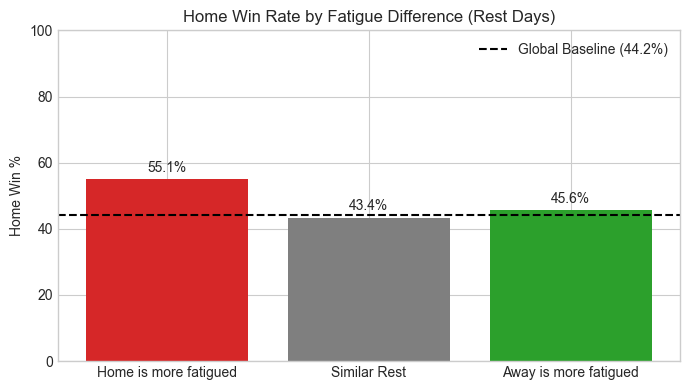

In [ ]:
# 1. Calculate Rest Days using the already sorted team_matches dataframe
team_matches['RestDays'] = team_matches.groupby('Team')['Date_dt'].diff().dt.days

# Fill the first match of the season with a standard off-season value (e.g., 30 days)
team_matches['RestDays'] = team_matches['RestDays'].fillna(30)

# 2. Merge back into the main DataFrame
home_rest = team_matches[team_matches['is_home'] == True][['Date_dt', 'Team', 'RestDays']]
away_rest = team_matches[team_matches['is_home'] == False][['Date_dt', 'Team', 'RestDays']]

premier_df = premier_df.merge(home_rest.rename(columns={'Team': 'HomeTeam', 'RestDays': 'HomeRestDays'}), on=['Date_dt', 'HomeTeam'], how='left')
premier_df = premier_df.merge(away_rest.rename(columns={'Team': 'AwayTeam', 'RestDays': 'AwayRestDays'}), on=['Date_dt', 'AwayTeam'], how='left')

# 3. Calculate Rest Difference
premier_df['Rest_Diff'] = premier_df['HomeRestDays'] - premier_df['AwayRestDays']

# --- Plotting the Evidence ---
fatigue_analysis = premier_df.dropna(subset=['Rest_Diff']).copy()
fatigue_analysis['HomeWin'] = fatigue_analysis['FTR'].eq('H').astype(int)

# Cap extreme rest differences (e.g., season breaks) to focus on normal congested fixtures
fatigue_analysis['Rest_Diff_Capped'] = fatigue_analysis['Rest_Diff'].clip(lower=-7, upper=7)

fatigue_analysis['Fatigue_Category'] = pd.cut(
    fatigue_analysis['Rest_Diff_Capped'], 
    bins=[-8, -3, 2, 8], 
    labels=['Home is more fatigued', 'Similar Rest', 'Away is more fatigued']
)

fatigue_summary = fatigue_analysis.groupby('Fatigue_Category', observed=True).agg(
    Home_Win_Rate=('HomeWin', lambda x: x.mean() * 100)
).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(fatigue_summary.index, fatigue_summary['Home_Win_Rate'], color=['#D62728', '#7F7F7F', '#2CA02C'])
ax.set(title='Home Win Rate by Fatigue Difference (Rest Days)', ylabel='Home Win %', ylim=(0, 100))
ax.axhline(44.2, color='black', linestyle='--', label='Global Baseline (44.2%)')
for container in ax.containers: ax.bar_label(container, fmt='%.1f%%', padding=3, size=10)
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation & Critical Dataset Limitation

*   **Observation:** Counterintuitively, when the Home team appears more fatigued (fewer rest days), their win rate spikes to **55.1%**, well above the 44.2% baseline. 
*   **Critical Data Blind Spot:** This dataset *only* tracks Premier League matches. Therefore, our `RestDays` calculation is completely blind to FA Cup, League Cup, and European matches (Champions/Europa League). A team might show "7 days rest" in this dataset but actually played a Champions League match mid-week.
*   **Domain Insight:** The teams have fewer rest days mostly during the festive period (where everyone is fatigued) or during rescheduled matches. Rescheduled matches frequently involve top-tier teams who had to postpone league games because they advanced deep into cup competitions. Thus, our "fatigue" metric is accidentally capturing strong teams playing catch-up games.
*   **Conclusion for Modeling:** Because this dataset cannot accurately capture true physical fatigue without external competition data, `Rest_Diff` is a heavily biased and incomplete feature, and we should'nt use this feature and rely on Betting Odds and `Form_Diff` to capture team strength and momentum.

# 7. Conclusions and roadmap

## Descriptive findings

1. `FTR` se asocia fuertemente con la localía: 44.2% victorias locales, 31.9% visitantes y 23.9% empates. La ventaja de jugar en casa (~12 puntos porcentuales) es un fenómeno general de la liga, no un artefacto de unos pocos equipos.
2. Las cuotas de las casas, transformadas a probabilidad implícita (`p(H)`, `p(D)`, `p(A)`), son la señal pre-partido más fuerte disponible y su poder predictivo es estable entre temporadas.
3. La missingness se concentra en las cuotas: 7 casas de apuestas superan el 80% de datos faltantes, mientras que `match_stats` no tiene ninguno.
4. La ausencia de equipos en ciertas temporadas (ascensos y descensos) es informativa: los equipos presentes las 5 temporadas ganan ~44% de sus partidos, los que estuvieron solo una, ~17%.
5. `AHh` (handicap asiático) resume la fuerza relativa de los equipos y su relación con la victoria local es estable entre temporadas.
6. `HTR` amplifica la señal de `p(H)`, pero solo se conoce al medio tiempo: es un feature legítimo únicamente para un modelo en vivo.
7. Las 16 columnas de `match_stats` se relacionan con el resultado, pero solo se conocen después del pitido final y filtrarían información futura: no deben usarse para predecir.

## Hypotheses to validate during modeling

| Variable | Candidate strategy | Caution |
|---|---|---|
| Identificador compuesto (`Season`, `Div`, `Date`, `Time`, `HomeTeam`, `AwayTeam`) | Excluir o usar como agrupación temporal | Identifica cada partido |
| `Season` | Codificación ordinal o categórica | No extrapolar más allá de 2021–2026 |
| `Div` | Excluir | Solo tiene un valor (E0) |
| `Date`, `Time` | Parsear `Date` como datetime; probar si `Time` aporta señal | No dejarlas como strings |
| `HomeTeam`, `AwayTeam` | Resumir a una medida de fuerza del equipo | No tratar como 27 categorías sueltas; ~19 partidos por equipo y temporada |
| `Referee` | Resumir o excluir | Muestras muy pequeñas y asignación no aleatoria |
| `HTR`, `HTHG`, `HTAG` | Usar solo en modelo en vivo | No disponibles antes del partido |
| `match_stats` (16 columnas) | Excluir | Se conocen solo al terminar el partido: leakage |
| Cuotas (132 columnas) | Probabilidad implícita; preferir casas completas (B365, Max, Avg) | 7 casas con ~80% de missing; alta redundancia entre mercados |
| Mercados `>2.5` y `AHh` | Probar como features complementarias | Redundantes con el mercado 1X2 |

## Limitations

- El dataset contiene 1900 partidos y varios subgrupos tienen muy pocas observaciones.
- Las asociaciones no demuestran causalidad.
- Los cortes de los bins (por ejemplo, Bajo/Medio/Alto de `p(H)`) son decisiones analíticas ajustables.
- Cualquier transformación, imputación o selección de características debe realizarse dentro del pipeline usando solo datos de entrenamiento.

The next step is not to assume that these decisions are correct, but to compare them using cross-validation and appropriate metrics.